<h1 style='text-align:center; font-weight:bold; color:orange'>Understanding User Preferences: Insights from Website Survey Data Using a 10-Point Likert Scale</h1>

## **1 Scenario**
- The dataset was obtained from [Faisal et al (2017)](https://doi.org/10.1109/THMS.2016.2620901) via [Hayri](https://www.kaggle.com/datasets/hayriyigit/website-satisfaction-survey) on Kaggle.
- Intended for simple data analysis. It does not involve any inferential statistical test and predictive modeling technique. This analysis only covers primarily data visualization for 10-point Likert scale.

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

## **2 Data Preparation**

In [33]:
# load data
df = pd.read_csv('../data/survey.csv')

# check snippet of data
df.iloc[0:6, 0:15].style.set_caption('Website Satisfaction Survey Data')

,user_id,language,platform,gender,age,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10
0,080c468b-27c0-455c-aa63-b8f807f2e3d7,en,Desktop,male,34,9,7,6,6,7,7,6,6,5,5
1,0b0379c7-04db-4c85-84bd-a2bd55329e29,en,Mobile,female,19,10,10,10,9,10,10,10,10,9,10
2,0e623280-b28b-4d4a-8eea-0732f09ed497,en,Mobile,female,19,10,10,10,10,10,10,10,10,10,10
3,045dc0f3-a730-4d03-a615-f51814e5b04f,en,Mobile,male,21,5,8,5,5,5,5,5,6,6,8
4,092f2ee7-5281-4a09-9bce-e5523b95b53b,en,nan,female,53,9,10,9,10,9,7,8,5,7,8
5,19c0851c-cbb1-45b5-9e78-884b761802ac,en,Mobile,female,53,10,9,9,9,5,6,8,7,4,5


In [34]:
# create function to inspect df
def inspect_dataframe(df):
    summary = {
        'ColumnName': df.columns.values.tolist(),
        'Nrow': df.shape[0],
        'DataType': df.dtypes.values.tolist(),
        'NAPct': (df.isna().mean() * 100).round(2).tolist(),
        'DuplicatePct': (df.duplicated().sum()/len(df)*100).round(2),
        'UniqueValue': df.nunique().tolist(),
        'Sample': [df[col].unique() for col in df.columns]
    }
    return pd.DataFrame(summary)

In [35]:
# inspect dataframe
print(f'The dataframe contains {df.shape[0]} rows and {df.shape[1]} cols.')
print(f"- {len(df.select_dtypes(include='number').columns)} are numeric cols")
print(f"- {len(df.select_dtypes(include='O').columns)} are object cols")
inspect_dataframe(df)

The dataframe contains 73 rows and 31 cols.
- 27 are numeric cols
- 4 are object cols


,ColumnName,Nrow,DataType,NAPct,DuplicatePct,UniqueValue,Sample
0,user_id,73,object,0.00,0.0,73,"[080c468b-27c0-455c-aa63-b8f807f2e3d7, 0b0379c..."
1,language,73,object,0.00,0.0,2,"[en, es]"
2,platform,73,object,10.96,0.0,2,"[Desktop, Mobile, nan]"
3,gender,73,object,0.00,0.0,3,"[male, female, other]"
4,age,73,int64,0.00,0.0,24,"[34, 19, 21, 53, 18, 20, 13, 29, 46, 44, 2, 27..."
5,q1,73,int64,0.00,0.0,9,"[9, 10, 5, 8, 7, 4, 3, 6, 1]"
6,q2,73,int64,0.00,0.0,10,"[7, 10, 8, 9, 5, 4, 6, 3, 2, 1]"
7,q3,73,int64,0.00,0.0,10,"[6, 10, 5, 9, 7, 4, 8, 2, 3, 1]"
8,q4,73,int64,0.00,0.0,9,"[6, 9, 10, 5, 7, 8, 4, 3, 2]"
9,q5,73,int64,0.00,0.0,8,"[7, 10, 5, 9, 6, 8, 4, 2]"


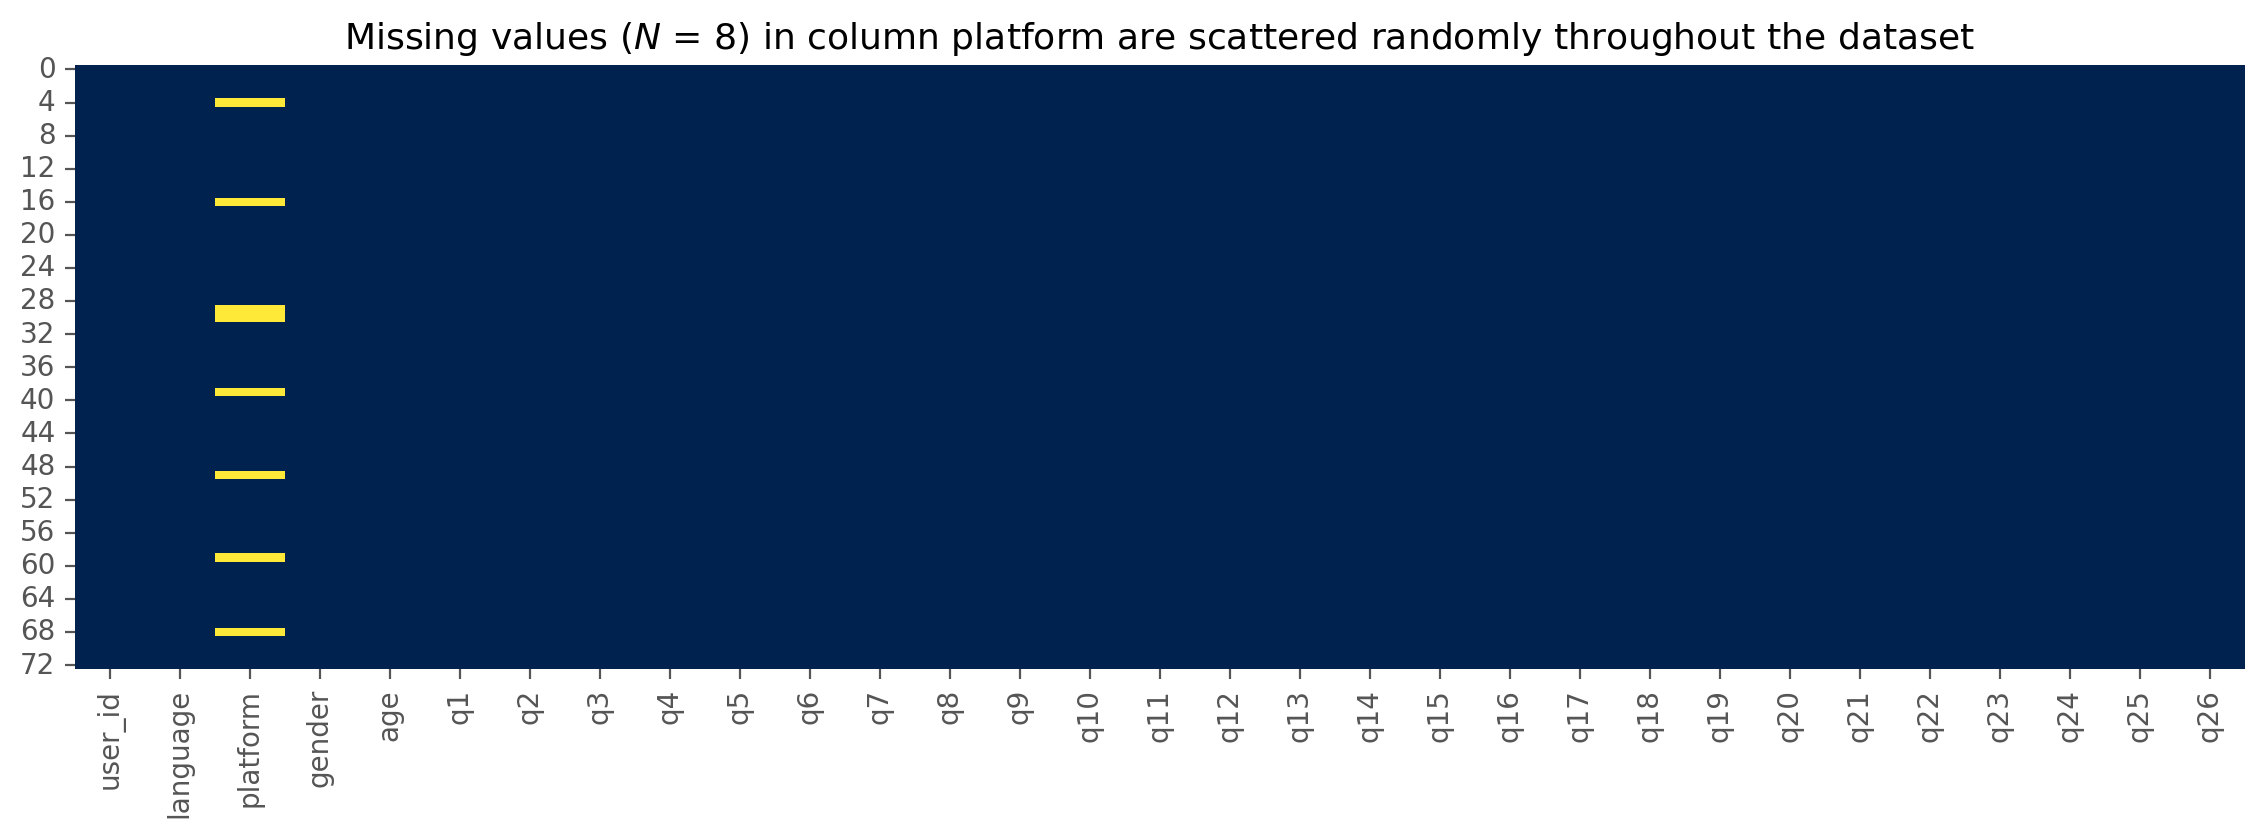

In [36]:
# check columns with missing values
plt.figure(figsize=(14, 4), dpi=200)
n_isna = df['platform'].isna().sum()
sns.heatmap(df.isna(), cmap=mpl.colormaps['cividis'], cbar=False)
plt.title(f'Missing values ($N$ = {n_isna:,}) in column platform are scattered randomly throughout the dataset', fontsize=13)
plt.ylabel(None)
plt.show()

**Note**: Data visualization logic. If there are missing values (`True`), the heatmap plot will indicate stips whose color is different from the surroundings (not missing alias `False`). In the data visualization above, when missing value is True, the heatmap displays yellow color whereas non-missing data will have dark blue color.

In [37]:
# check records with missing values
df[df['platform'].isna()].iloc[:, 0:6]

,user_id,language,platform,gender,age,q1
4,092f2ee7-5281-4a09-9bce-e5523b95b53b,en,NaN,female,53,9
16,10e9b324-156e-4eb5-aec5-04d8a4d7124c,en,NaN,male,46,4
29,25602500-ca31-4404-b155-3e070652c2c0,en,NaN,other,1,7
30,11cbc3a6-1c92-4f10-abe6-27def200d91d,en,NaN,male,25,10
39,40d5e94f-2468-4f73-a0a0-e5a2c0443f06,en,NaN,other,1,6
49,e5eccf62-17fb-4353-b886-e547a9699dd4,en,NaN,male,45,8
59,ba4eba66-ab7c-4704-84e8-4218f019f196,en,NaN,male,23,10
68,cb71d11a-4e8d-4ab8-80be-ac1f46f5b2d1,en,NaN,male,1,9


In [38]:
# perform imputation
df.loc[:, 'platform'] = df['platform'].fillna('Unknown')
print(f'Total missing values (after imputation): {df.isna().sum().sum()}')

Total missing values (after imputation): 0


## **3 Exploratory Data Analysis**

### **3.1 Demography of Respondents**

In [39]:
# prepare data
platform_df = (df['platform'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

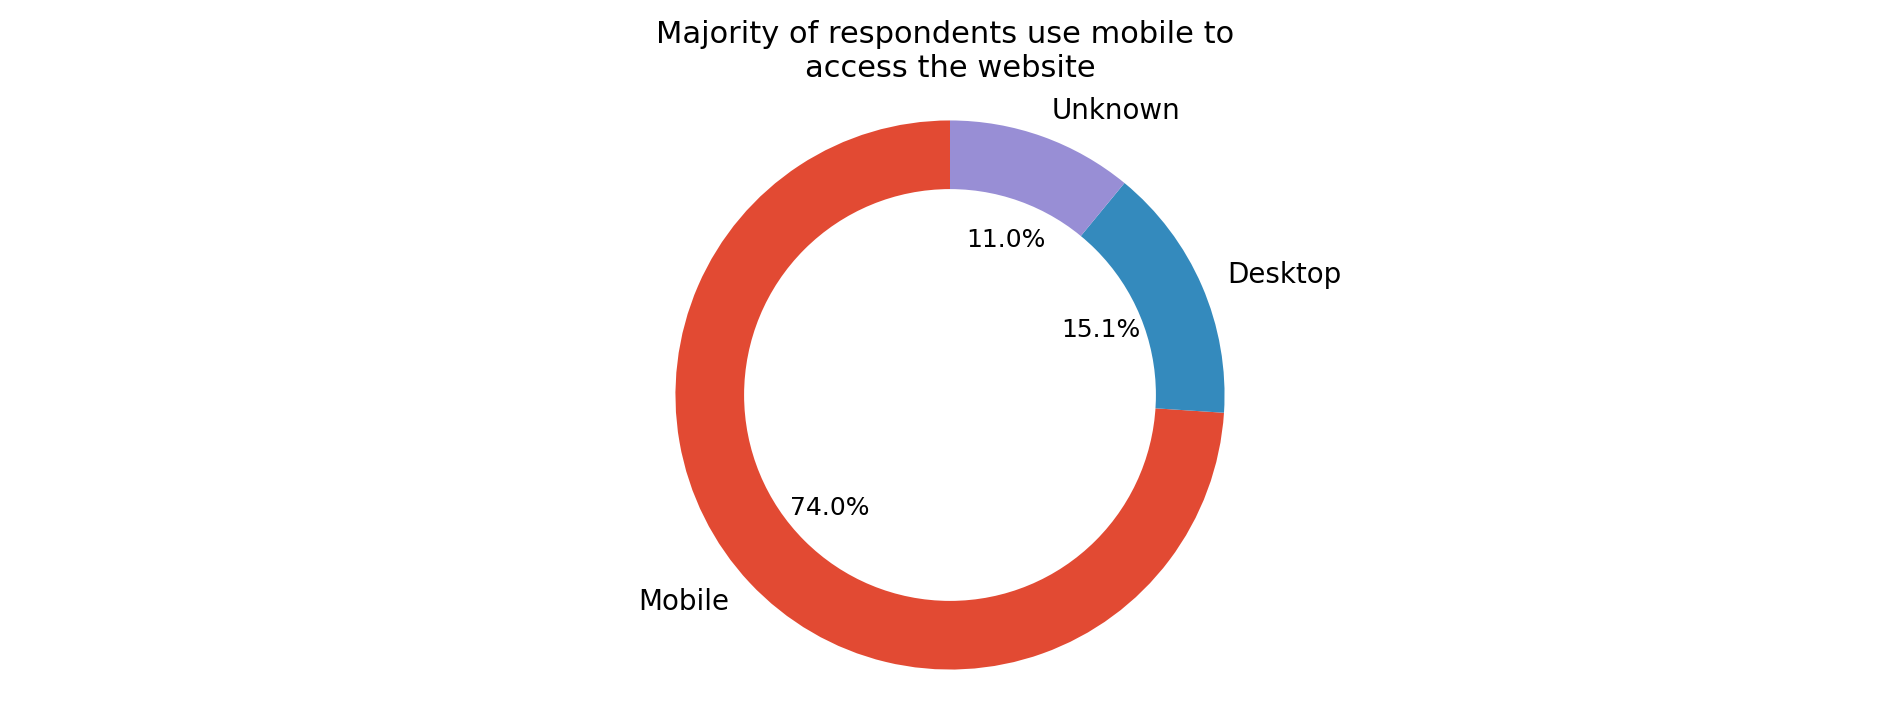

In [40]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(platform_df['proportion'], 
                                  labels=platform_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("Majority of respondents use mobile to \naccess the website", size=11)
plt.show()

In [41]:
# prepare data
language_df = (df['language'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

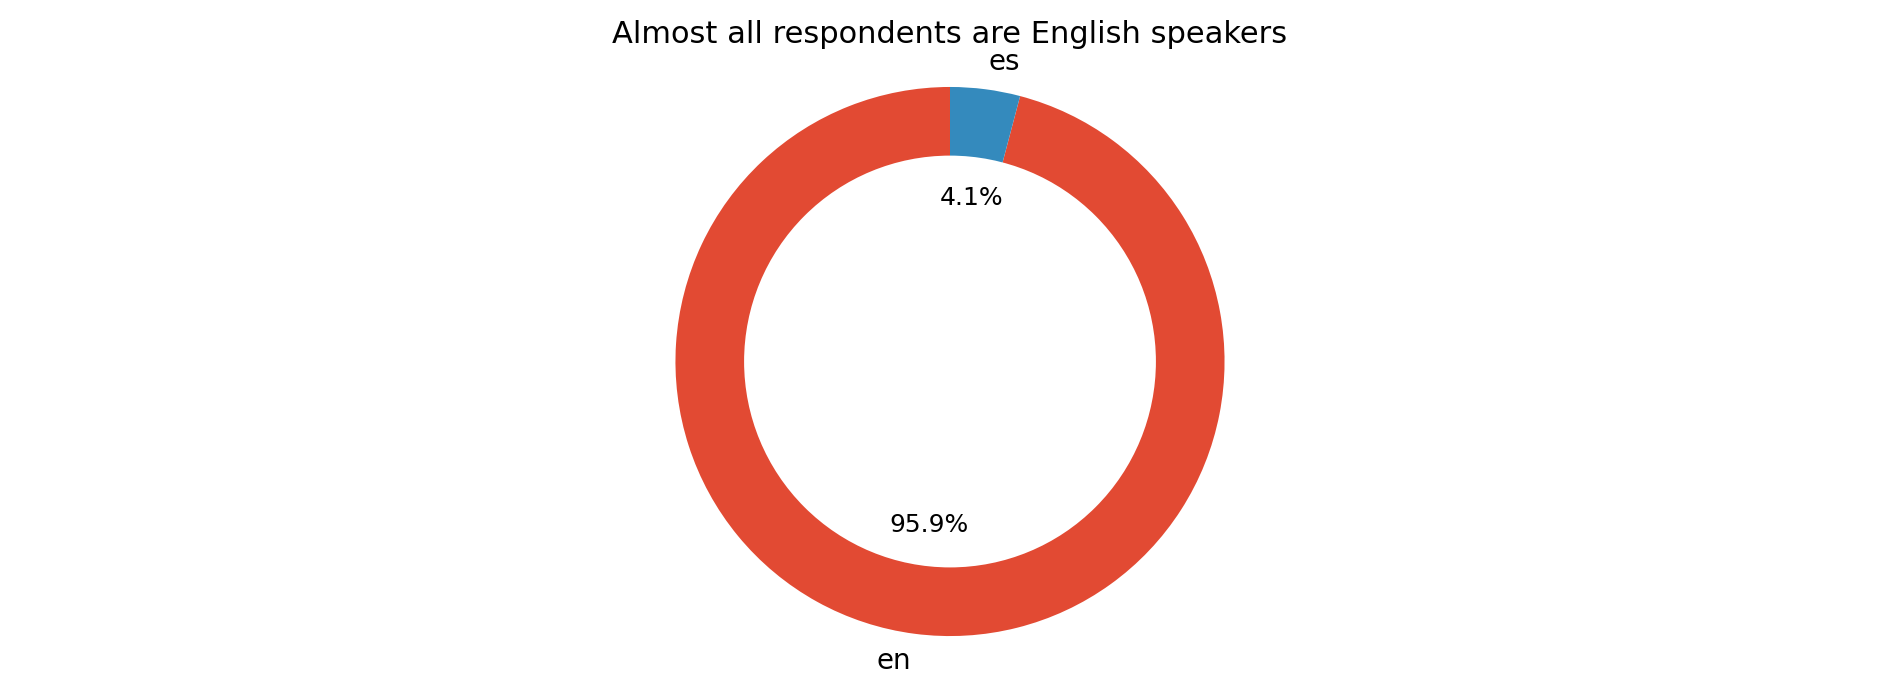

In [63]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(language_df['proportion'], 
                                  labels=language_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("Almost all respondents are English speakers", size=11)
plt.show()

In [43]:
# prepare data
gender_df = (df['gender'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

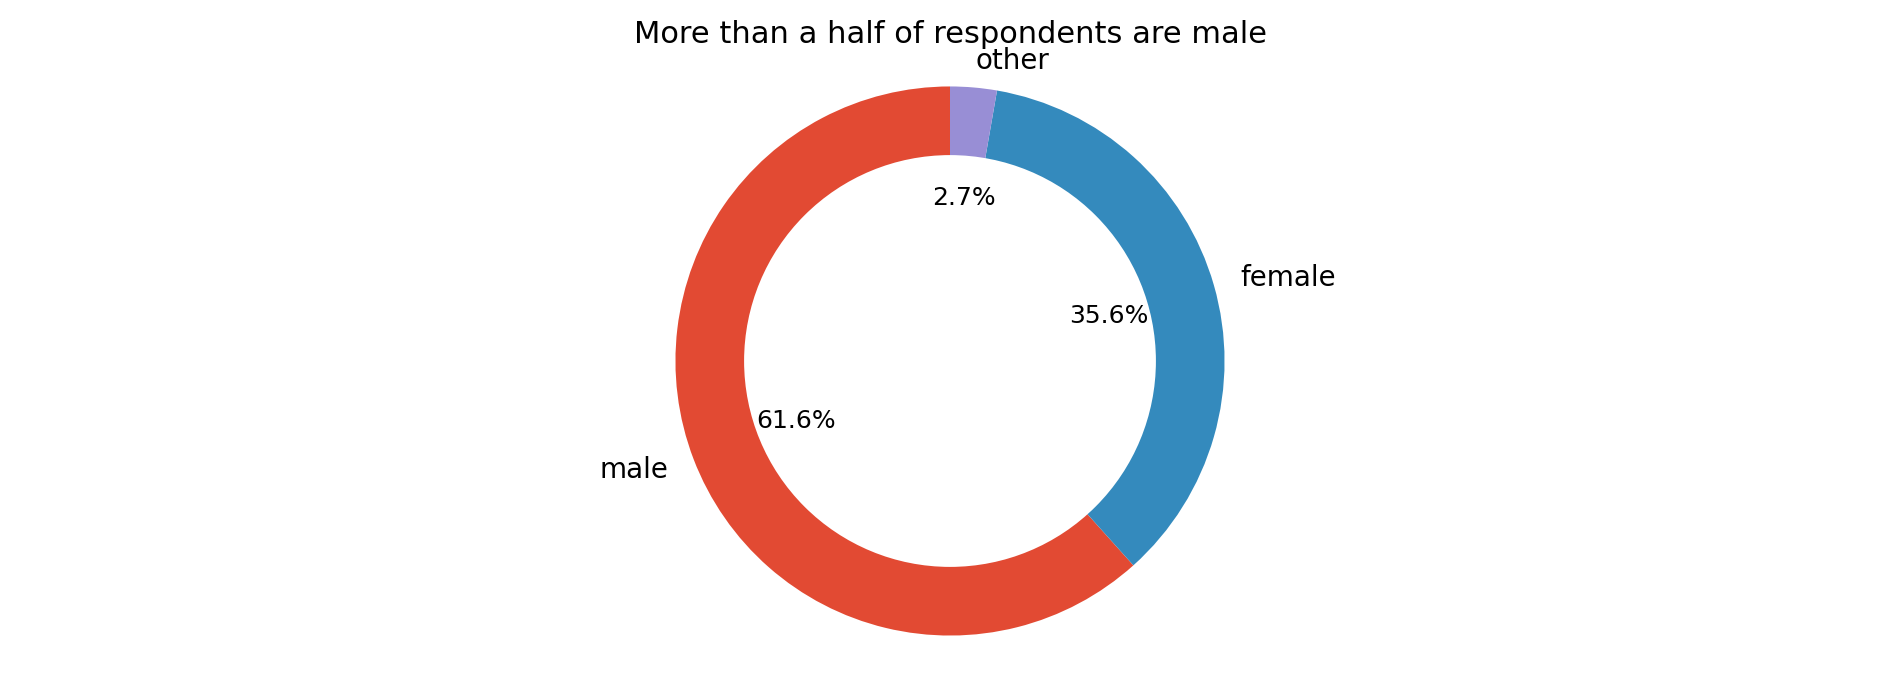

In [64]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(gender_df['proportion'], 
                                  labels=gender_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("More than a half of respondents are male", size=11)
plt.show()

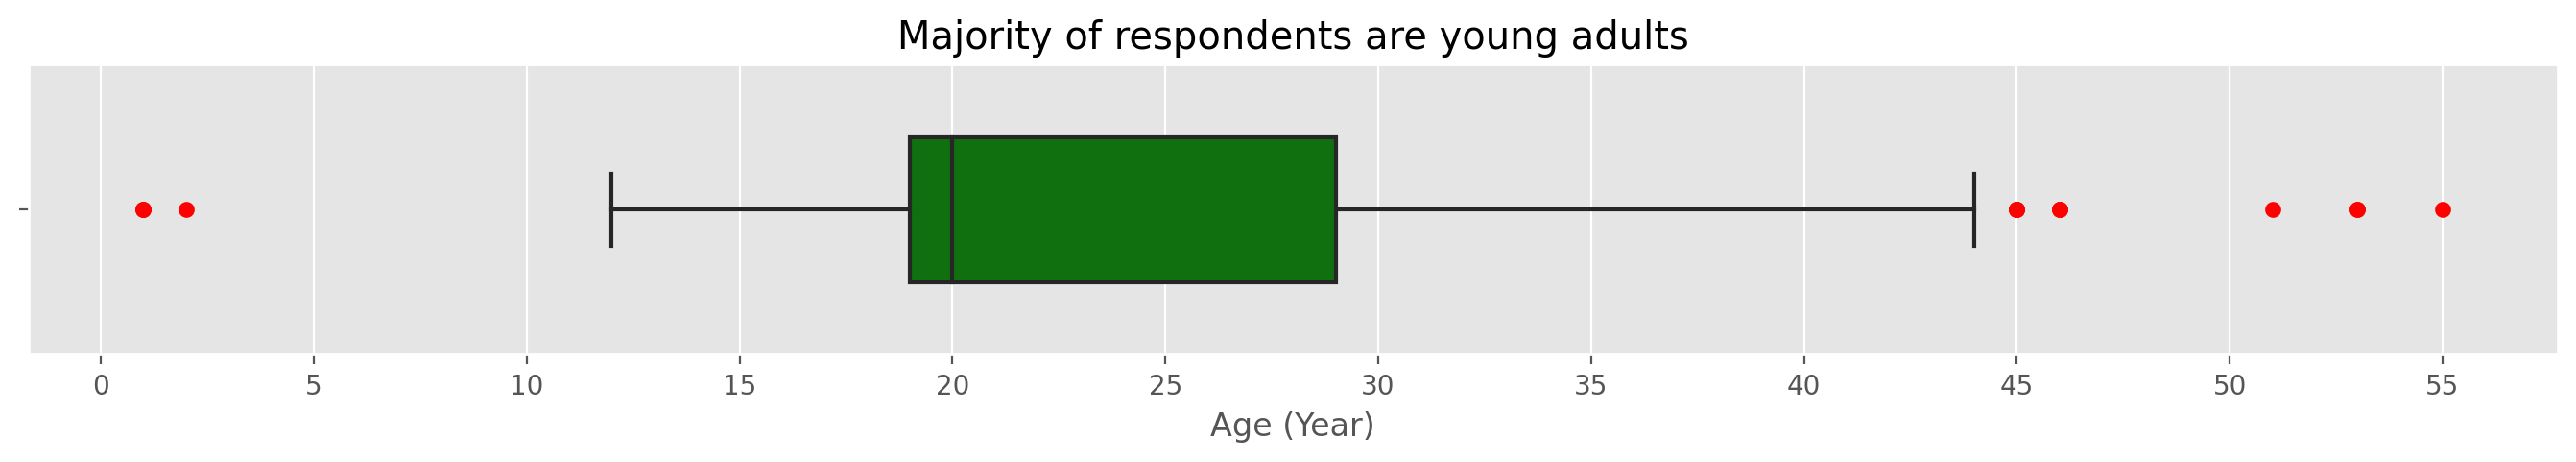

In [45]:
# create boxplot
plt.figure(figsize=(17, 2), dpi=200)
sns.boxplot(x=df['age'], color='green', width=0.5, 
            flierprops=dict(marker='.', markerfacecolor='red', 
                            markeredgecolor='red', alpha=1, 
                            markersize=10))

plt.title('Majority of respondents are young adults')
plt.xlabel('Age (Year)')
plt.xticks(range(0, 60, 5))
plt.show()

In [46]:
# replace values < 12
df.loc[df['age'] < 12, 'age'] = 12

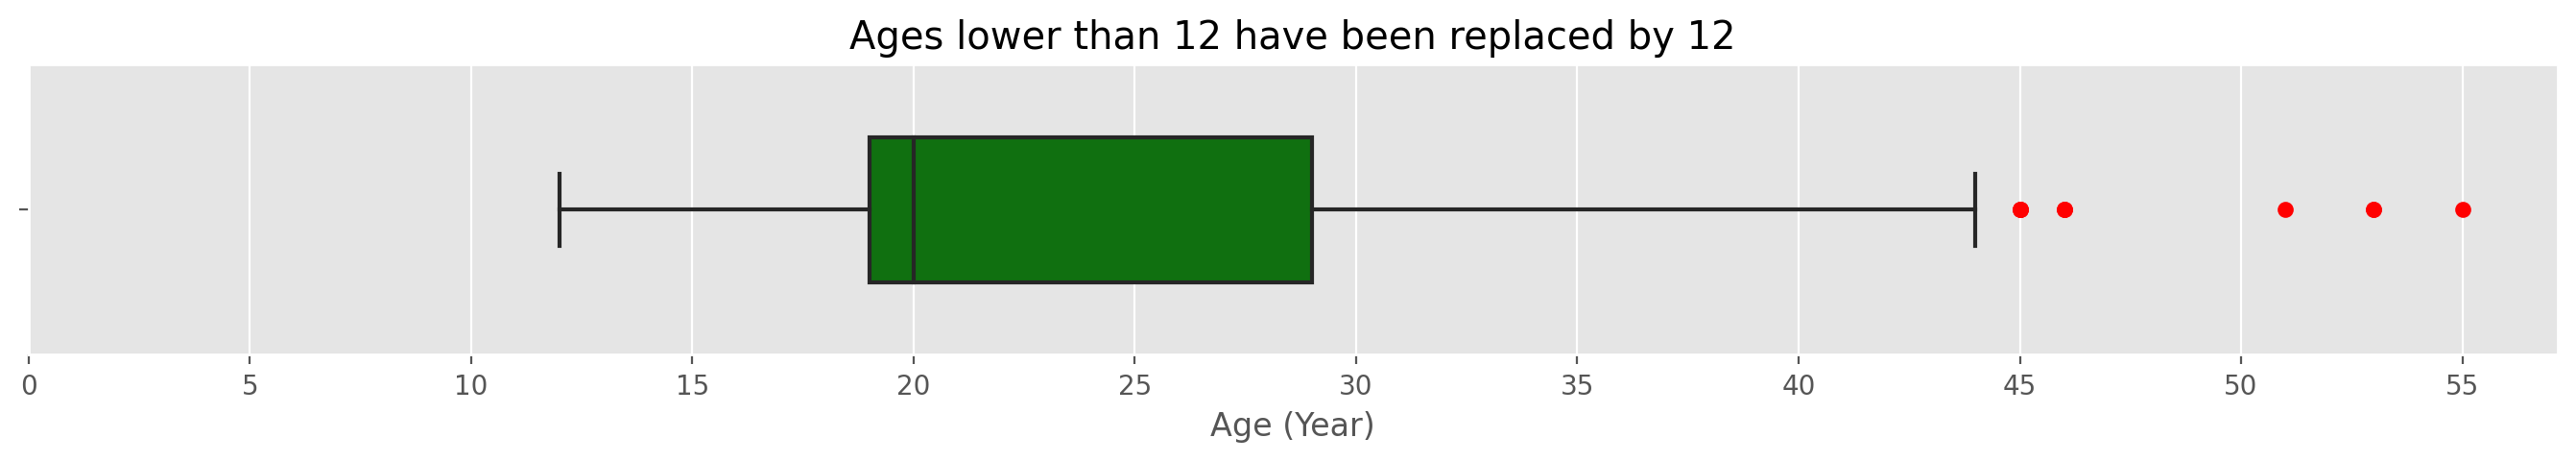

In [47]:
plt.figure(figsize=(17, 2), dpi=200)
sns.boxplot(x=df['age'], color='green', width=0.5, 
            flierprops=dict(marker='.', markerfacecolor='red', 
                            markeredgecolor='red', alpha=1, 
                            markersize=10))

plt.title('Ages lower than 12 have been replaced by 12')
plt.xlabel('Age (Year)')
plt.xticks(range(0, 60, 5))
plt.show()

In [48]:
# prepare data
cat_df = pd.crosstab(df['gender'], [df['platform'], df['language']], normalize=True) * 100

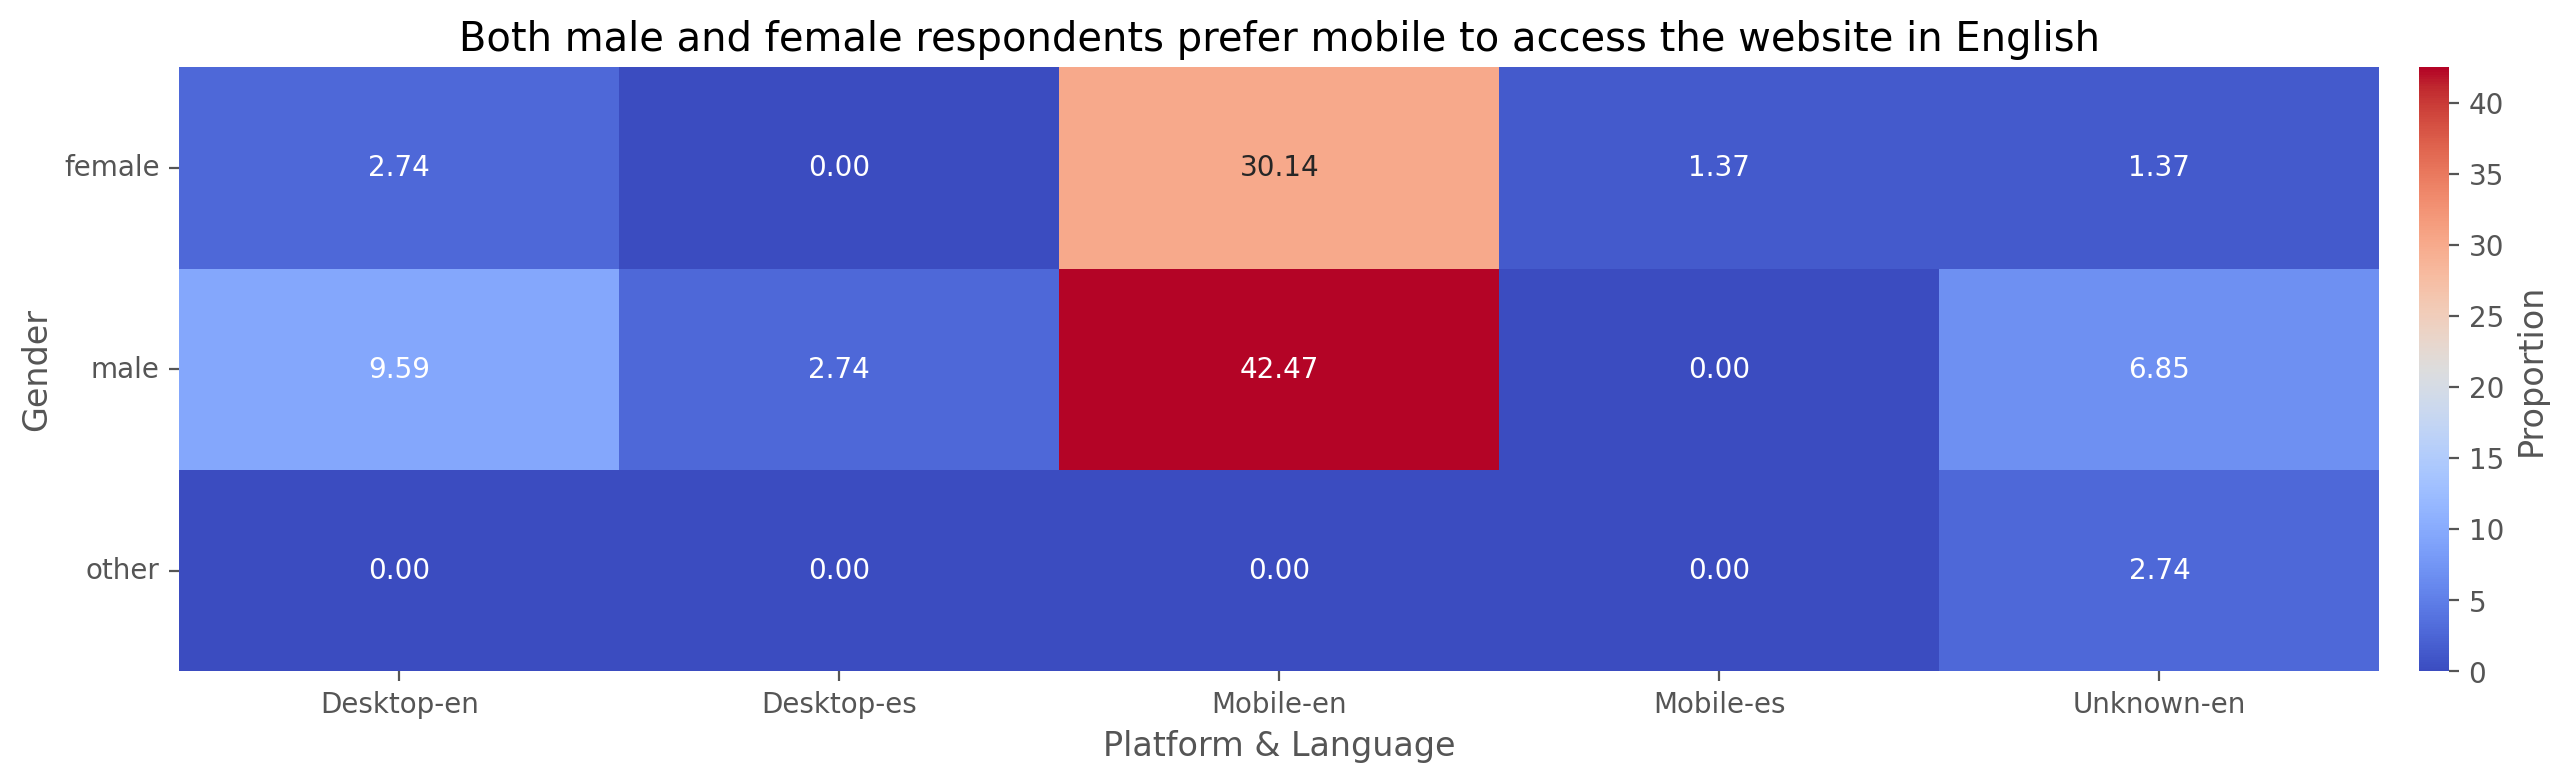

In [67]:
# make heatmap
plt.figure(figsize=(17,4), dpi=200)
sns.heatmap(cat_df, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label':'Proportion', 'pad': 0.015})
plt.title('Both male and female respondents prefer mobile to access the website in English')
plt.xlabel('Platform & Language')
plt.ylabel('Gender')
plt.yticks(rotation=0)
plt.show()

In [50]:
# subset dataset
q_columns = df.loc[:, 'q1':'q26']
q_columns.iloc[:5, :15]

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15
0,9,7,6,6,7,7,6,6,5,5,5,3,6,4,5
1,10,10,10,9,10,10,10,10,9,10,10,10,10,10,10
2,10,10,10,10,10,10,10,10,10,10,10,10,6,9,7
3,5,8,5,5,5,5,5,6,6,8,7,8,10,9,5
4,9,10,9,10,9,7,8,5,7,8,7,8,10,9,8


In [51]:
# get descriptive statistics
q_columns.describe().round(2).style.background_gradient(cmap='YlOrRd', axis=1).format("{:.2f}")

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26
count,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00
mean,8.01,7.86,7.82,7.41,7.51,7.64,7.63,7.60,7.07,6.44,7.05,6.86,7.53,7.68,7.58,7.04,8.07,7.45,7.47,7.41,7.59,7.81,7.56,7.48,7.56,7.33
std,2.20,1.95,2.23,2.04,1.76,2.00,1.96,1.91,2.28,2.32,2.07,2.39,1.95,1.86,2.15,2.14,2.07,2.04,2.30,2.18,2.41,2.19,2.47,2.30,2.28,2.33
min,1.00,1.00,1.00,2.00,2.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,7.00,7.00,7.00,6.00,7.00,7.00,7.00,7.00,6.00,5.00,6.00,5.00,6.00,7.00,7.00,6.00,7.00,6.00,6.00,6.00,7.00,7.00,6.00,7.00,7.00,6.00
50%,9.00,8.00,9.00,8.00,8.00,8.00,8.00,8.00,7.00,6.00,7.00,7.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
75%,10.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,8.00,8.00,9.00,9.00,9.00,9.00,9.00,10.00,9.00,9.00,9.00,9.00,9.00,10.00,9.00,9.00,9.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00


### **3.2 General Overview of the Satisfaction Survey**

In [68]:
# function to categorize responses
def categorize_response(score):
    if score <= 2:
        return 'Strongly Disagree'
    elif score <= 4:
        return 'Disagree'
    elif score <= 6:
        return 'Neutral'
    elif score <= 8:
        return 'Agree'
    else:
        return 'Strongly Agree'

# apply function
categorical_df = q_columns.applymap(categorize_response)

In [52]:
# calculate percentage of each category for each question
percentages = categorical_df.apply(lambda x: x.value_counts(normalize=True)
                                   .reindex(['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
                                            fill_value=0) * 100)
# transpose df
percentages = percentages.T

# rename index
percentages.index = [f'Q{i+1}' for i in range(len(percentages.index))]

# show in ascending order
percentages = percentages.iloc[::-1]
percentages.loc["Q5":"Q1", :]

,Strongly Disagree,Disagree,Neutral,Agree,Strongly Agree
Q5,2.739726,1.369863,20.547945,47.945205,27.397260
Q4,1.369863,9.589041,21.917808,28.767123,38.356164
Q3,4.109589,5.479452,15.068493,23.287671,52.054795
Q2,2.739726,4.109589,12.328767,36.986301,43.835616
Q1,4.109589,4.109589,9.589041,30.136986,52.054795


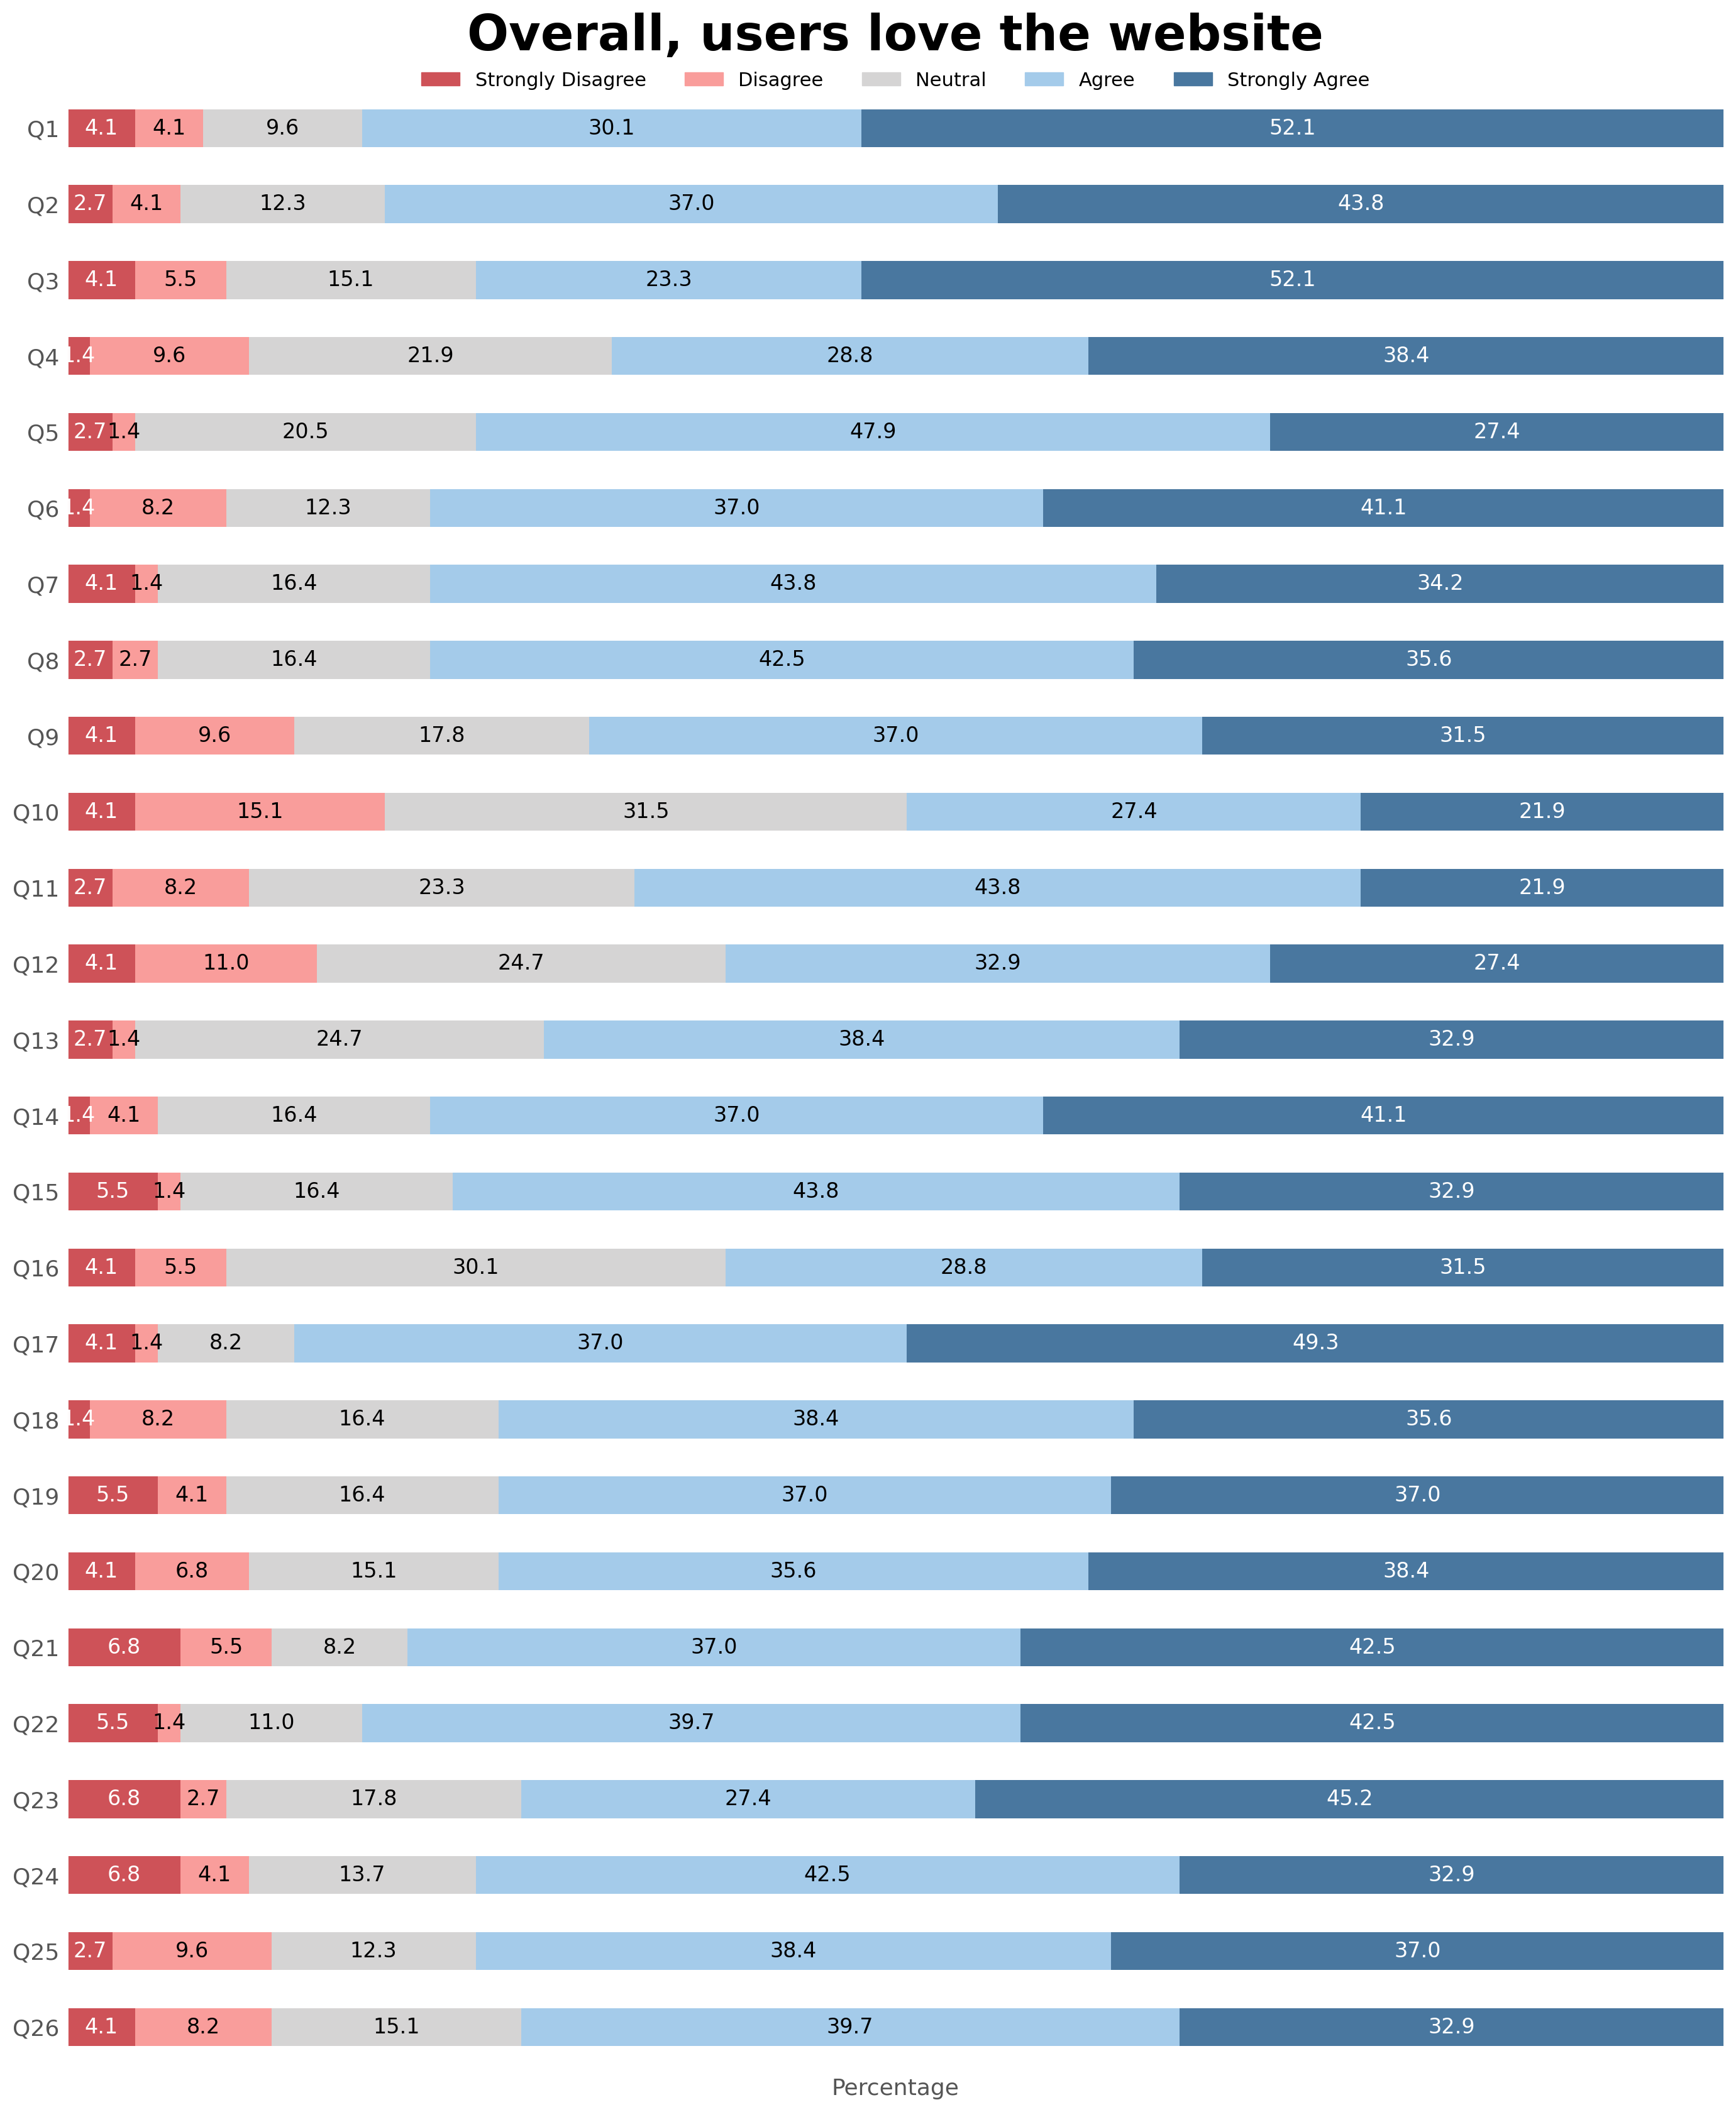

In [53]:
fig, ax = plt.subplots(figsize=(17, len(percentages.index) * 0.8), dpi=200)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
percentages.plot(kind='barh', stacked=True, color=colors, ax=ax)
ax.set_title('Overall, users love the website', y=1.015, weight='bold', size=28)
ax.set_xlabel('Percentage', size=13)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)                                                     # keep limits for percentage scale
ax.set_yticklabels(percentages.index, position=(-0.001, 0), size=13)    # Move y-ticks slightly to the left

# add data labels
for i in range(len(percentages)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += percentages.iloc[i, j]
        # change color for Strongly Disagree and Strongly Agree
        label_color = 'white' if j == 0 or j == 4 else 'black'  
        ax.text(cumulative - percentages.iloc[i, j]/2, i,
                f"{percentages.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=12)

# create custom legend
legend_labels = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']
handles = [Patch(color=colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]
ax.legend(handles=handles, bbox_to_anchor=(0.5, 1.005), loc='center', 
          ncol=5, facecolor='white', frameon=False, fontsize=11)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

### **3.3 Satisfaction Survey per UX Component**
#### **3.3.1 Typography**

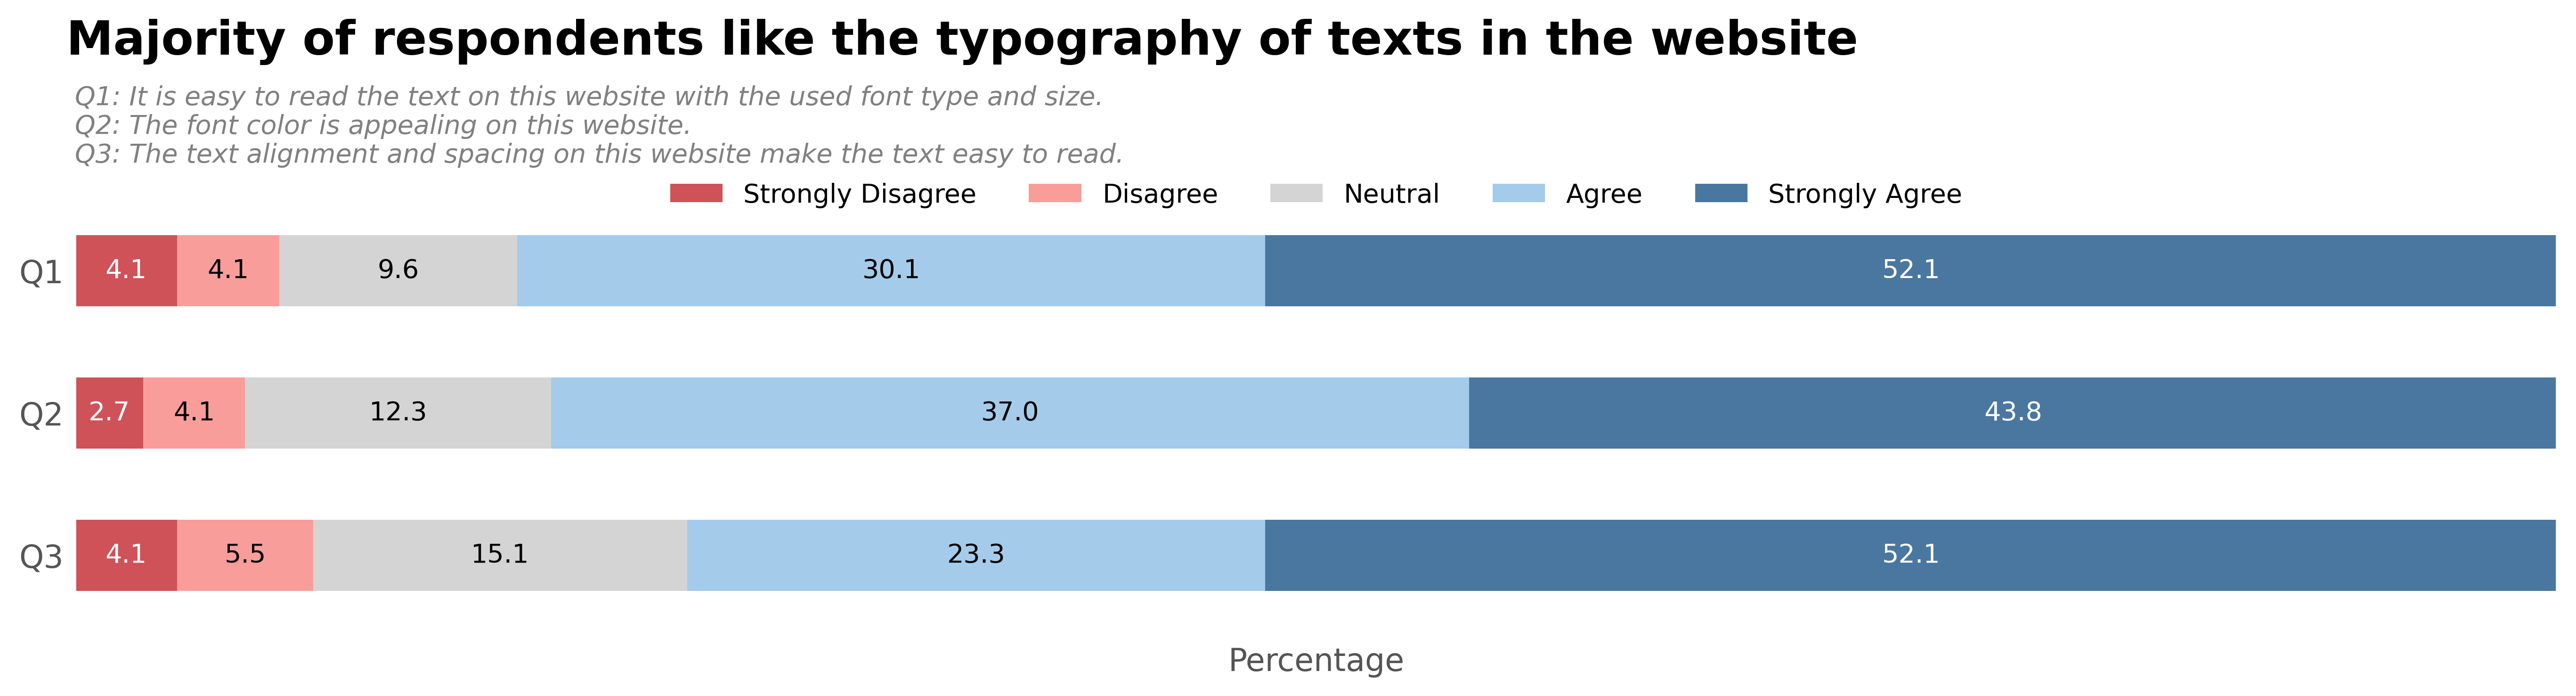

In [80]:
# Select specific questions to visualize
selected_questions = percentages.loc['Q3':'Q1', :]
# selected_questions = selected_questions.iloc[::1]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)

# add main title and subtitle
fig.suptitle('Majority of respondents like the typography of texts in the website', 
             y=1.2, size=18, x=0.402, weight='bold')
ax.set_title('Q1: It is easy to read the text on this website with the used font type and size.\n' 
             'Q2: The font color is appealing on this website.\n' 
             'Q3: The text alignment and spacing on this website make the text easy to read.', 
             fontsize=10, loc='left', y=1.05, color='grey',  style='italic')

ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)

# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=10)

ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.2 Colors**

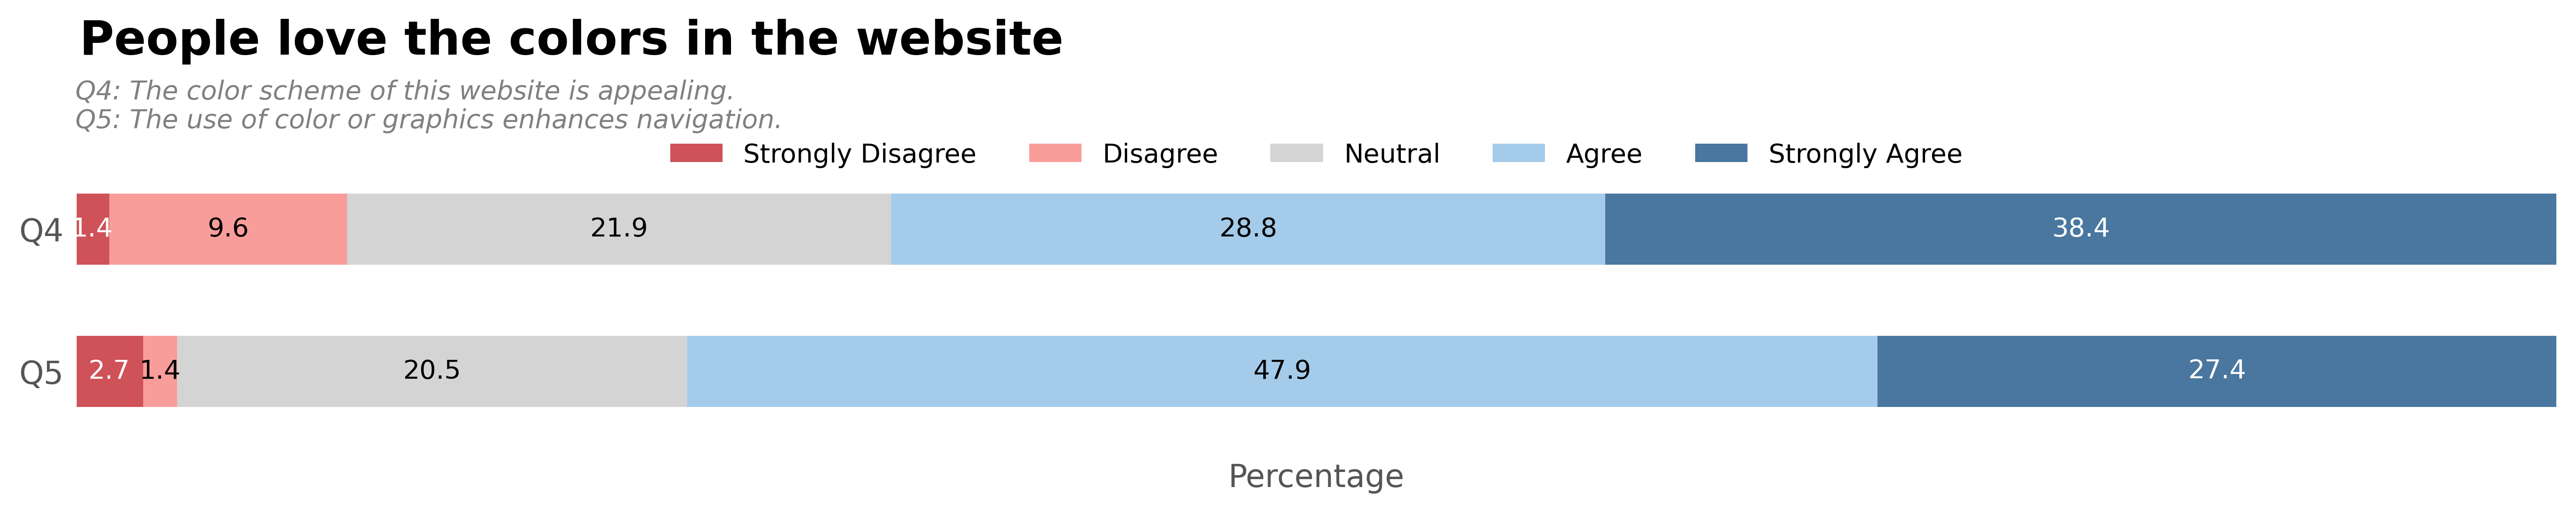

In [55]:
# select specific questions to visualize
selected_questions = percentages.loc['Q5':'Q4', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('People love the colors in the website', y=1.25, size=18, 
             x=0.28, weight='bold')
ax.set_title('Q4: The color scheme of this website is appealing.\n' 
             'Q5: The use of color or graphics enhances navigation.', 
             fontsize=10, loc='left', y=1.05, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=10)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.3. Content/information quality**

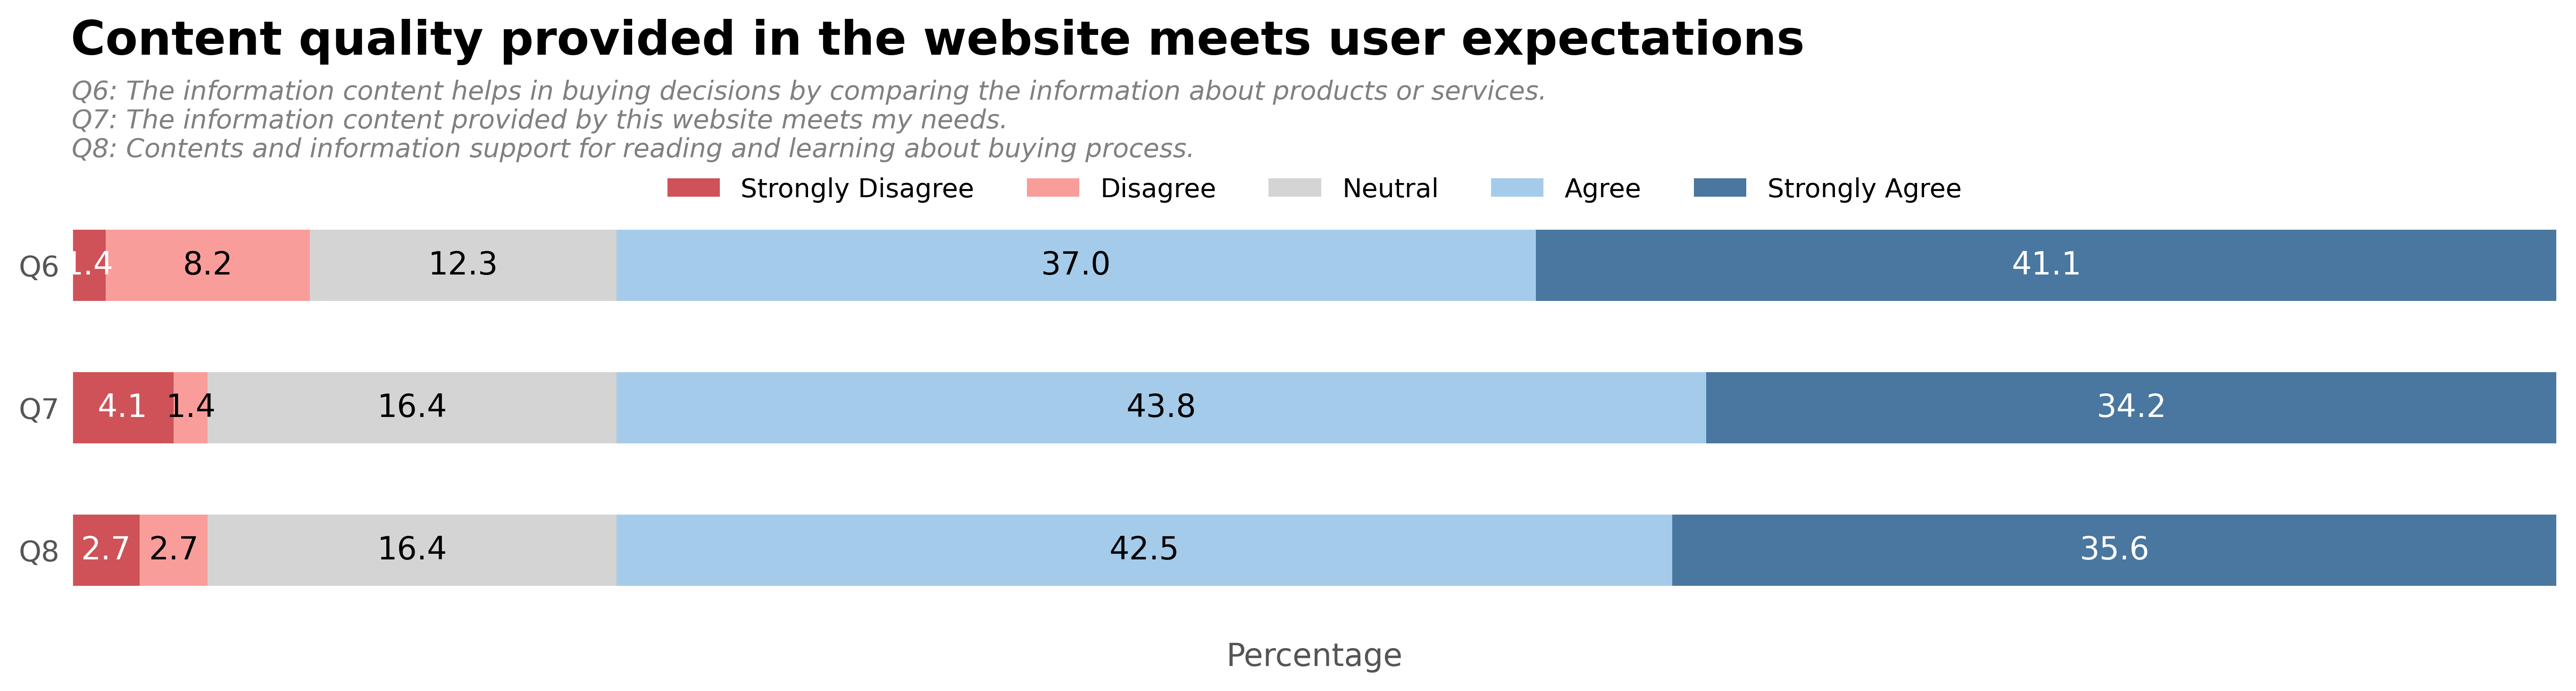

In [56]:
# select specific questions to visualize
selected_questions = percentages.loc['Q8':'Q6', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Content quality provided in the website meets user expectations', y=1.19, size=18, 
             x=0.395, weight='bold')
ax.set_title('Q6: The information content helps in buying decisions by comparing the information about products or services.\n' 
             'Q7: The information content provided by this website meets my needs.\n' 
             'Q8: Contents and information support for reading and learning about buying process.', 
             fontsize=10, loc='left', y=1.05, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=11)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=12)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.4 Interactivity**

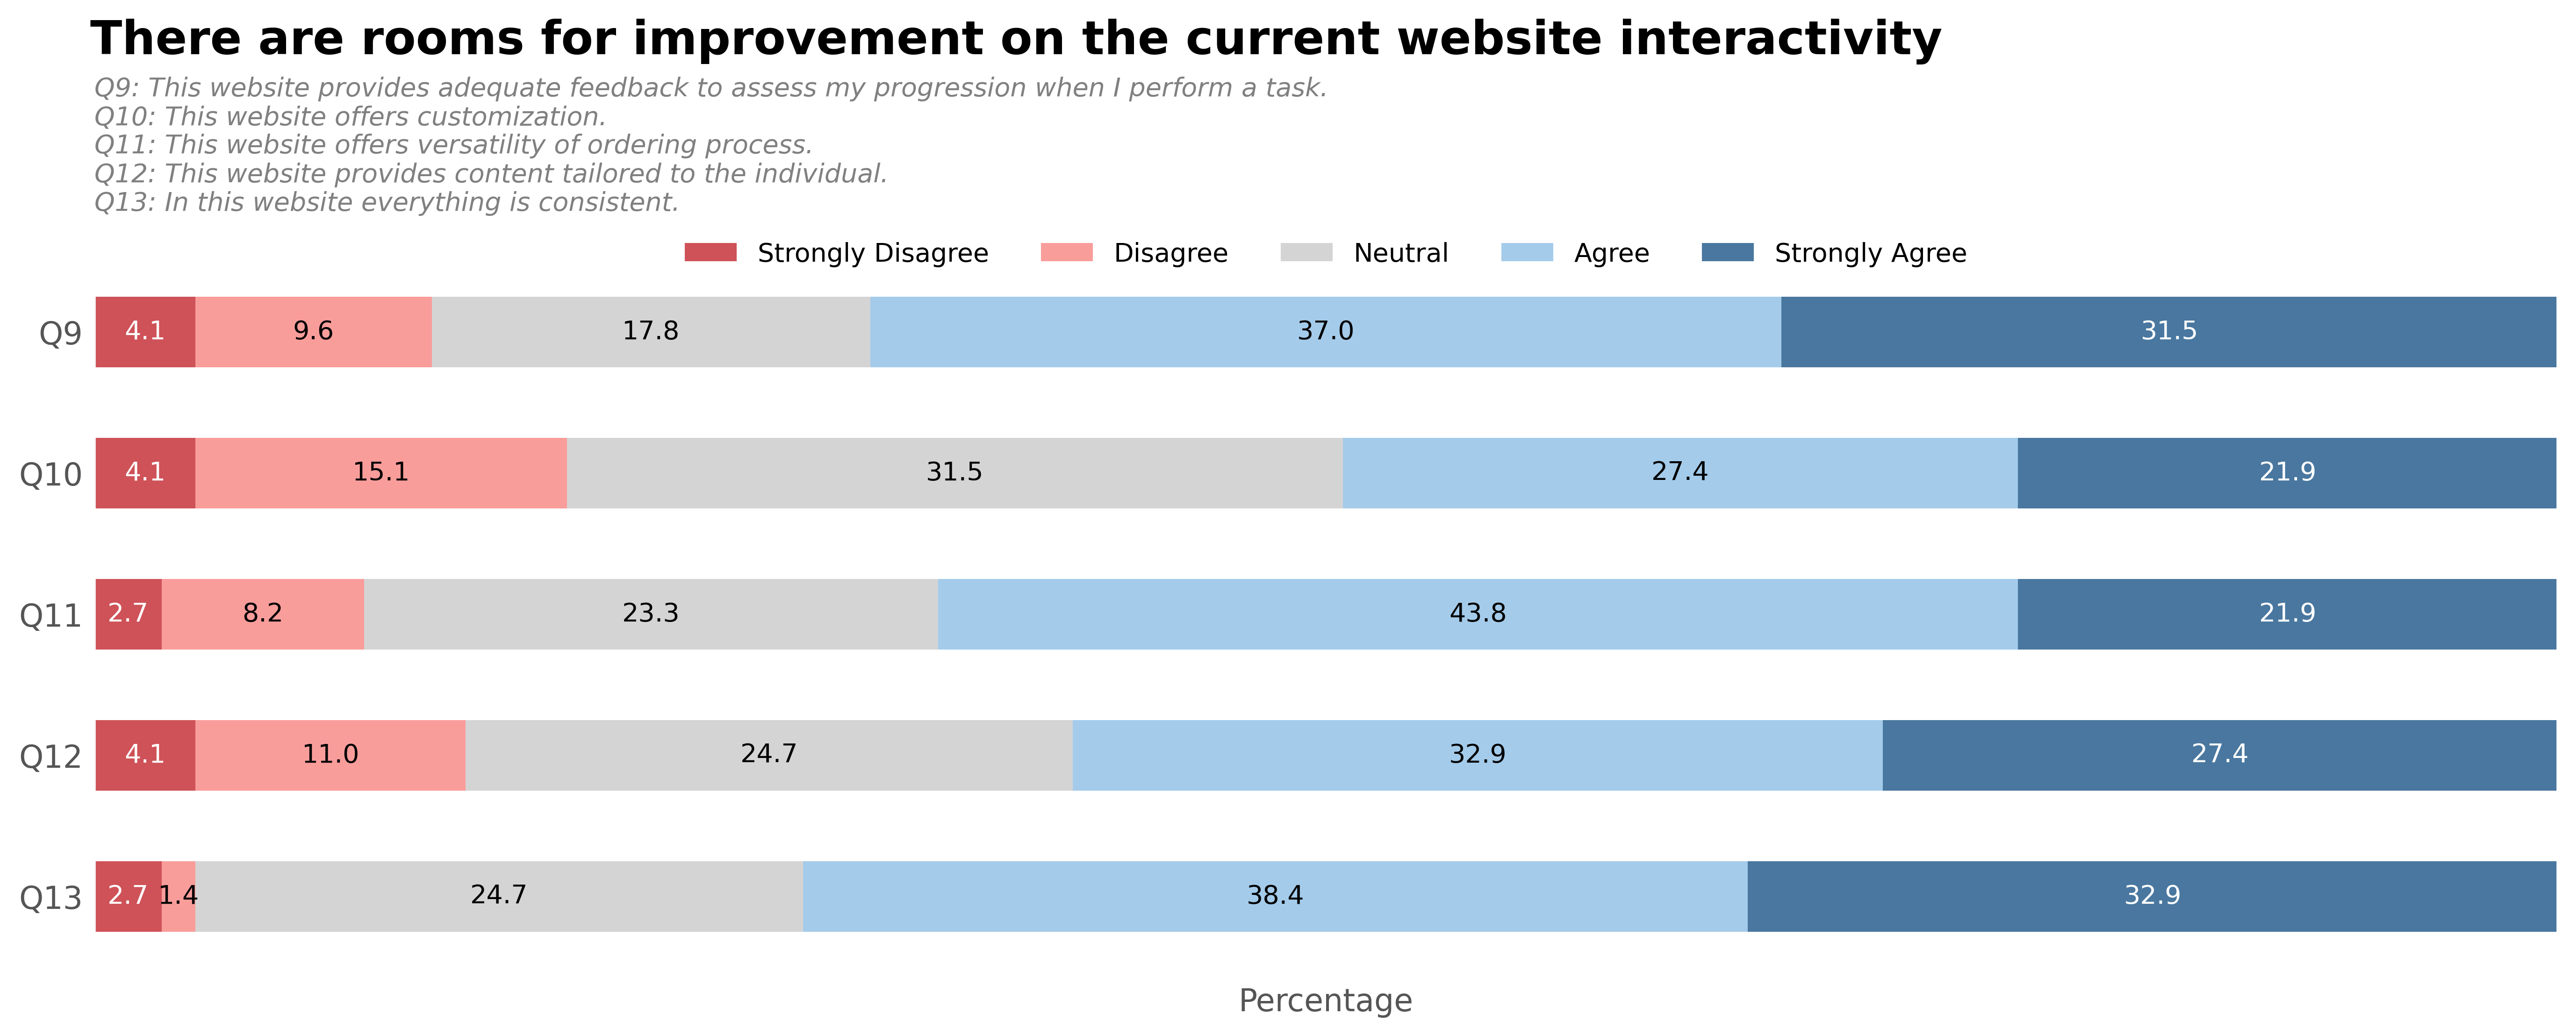

In [57]:
# select specific questions to visualize
selected_questions = percentages.loc['Q13':'Q9', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('There are rooms for improvement on the current website interactivity', y=1.14, size=18, 
             x=0.415, weight='bold')
ax.set_title('Q9: This website provides adequate feedback to assess my progression when I perform a task.\n' 
             'Q10: This website offers customization.\n' 
             'Q11: This website offers versatility of ordering process.\n' 
             'Q12: This website provides content tailored to the individual.\n' 
             'Q13: In this website everything is consistent.', 
             fontsize=10, loc='left', y=1.05, color='grey',  style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=10)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.5 Navigation**

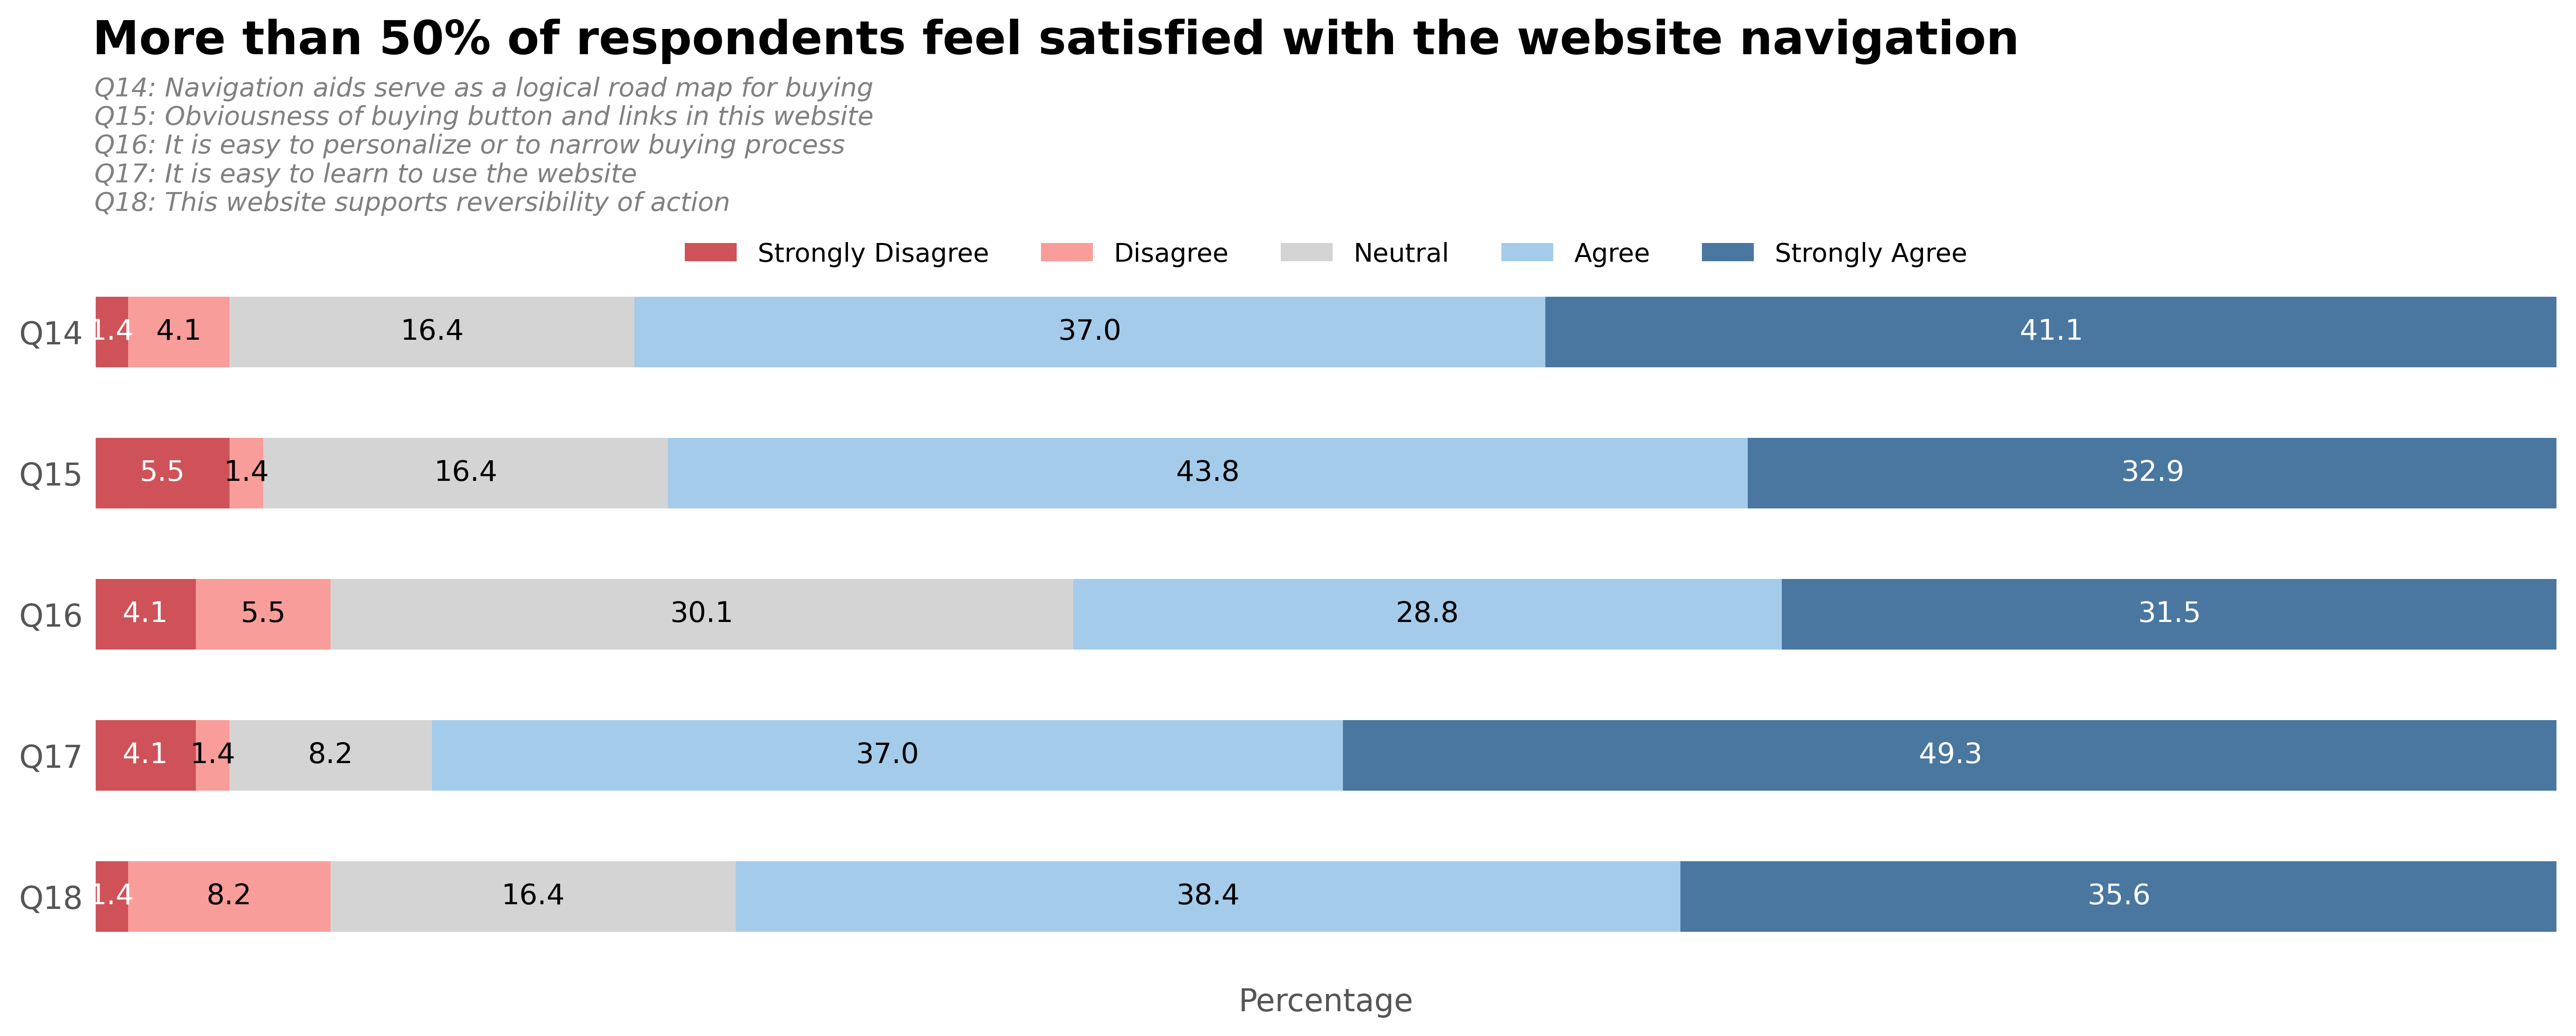

In [58]:
# select specific questions to visualize
selected_questions = percentages.loc['Q18':'Q14', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('More than 50% of respondents feel satisfied with the website navigation', 
             y=1.14, size=18, x=0.4275, weight='bold')
ax.set_title('Q14: Navigation aids serve as a logical road map for buying\n' 
             'Q15: Obviousness of buying button and links in this website\n' 
             'Q16: It is easy to personalize or to narrow buying process\n' 
             'Q17: It is easy to learn to use the website\n' 
             'Q18: This website supports reversibility of action', 
             fontsize=10, loc='left', y=1.05, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.6 Satisfaction**

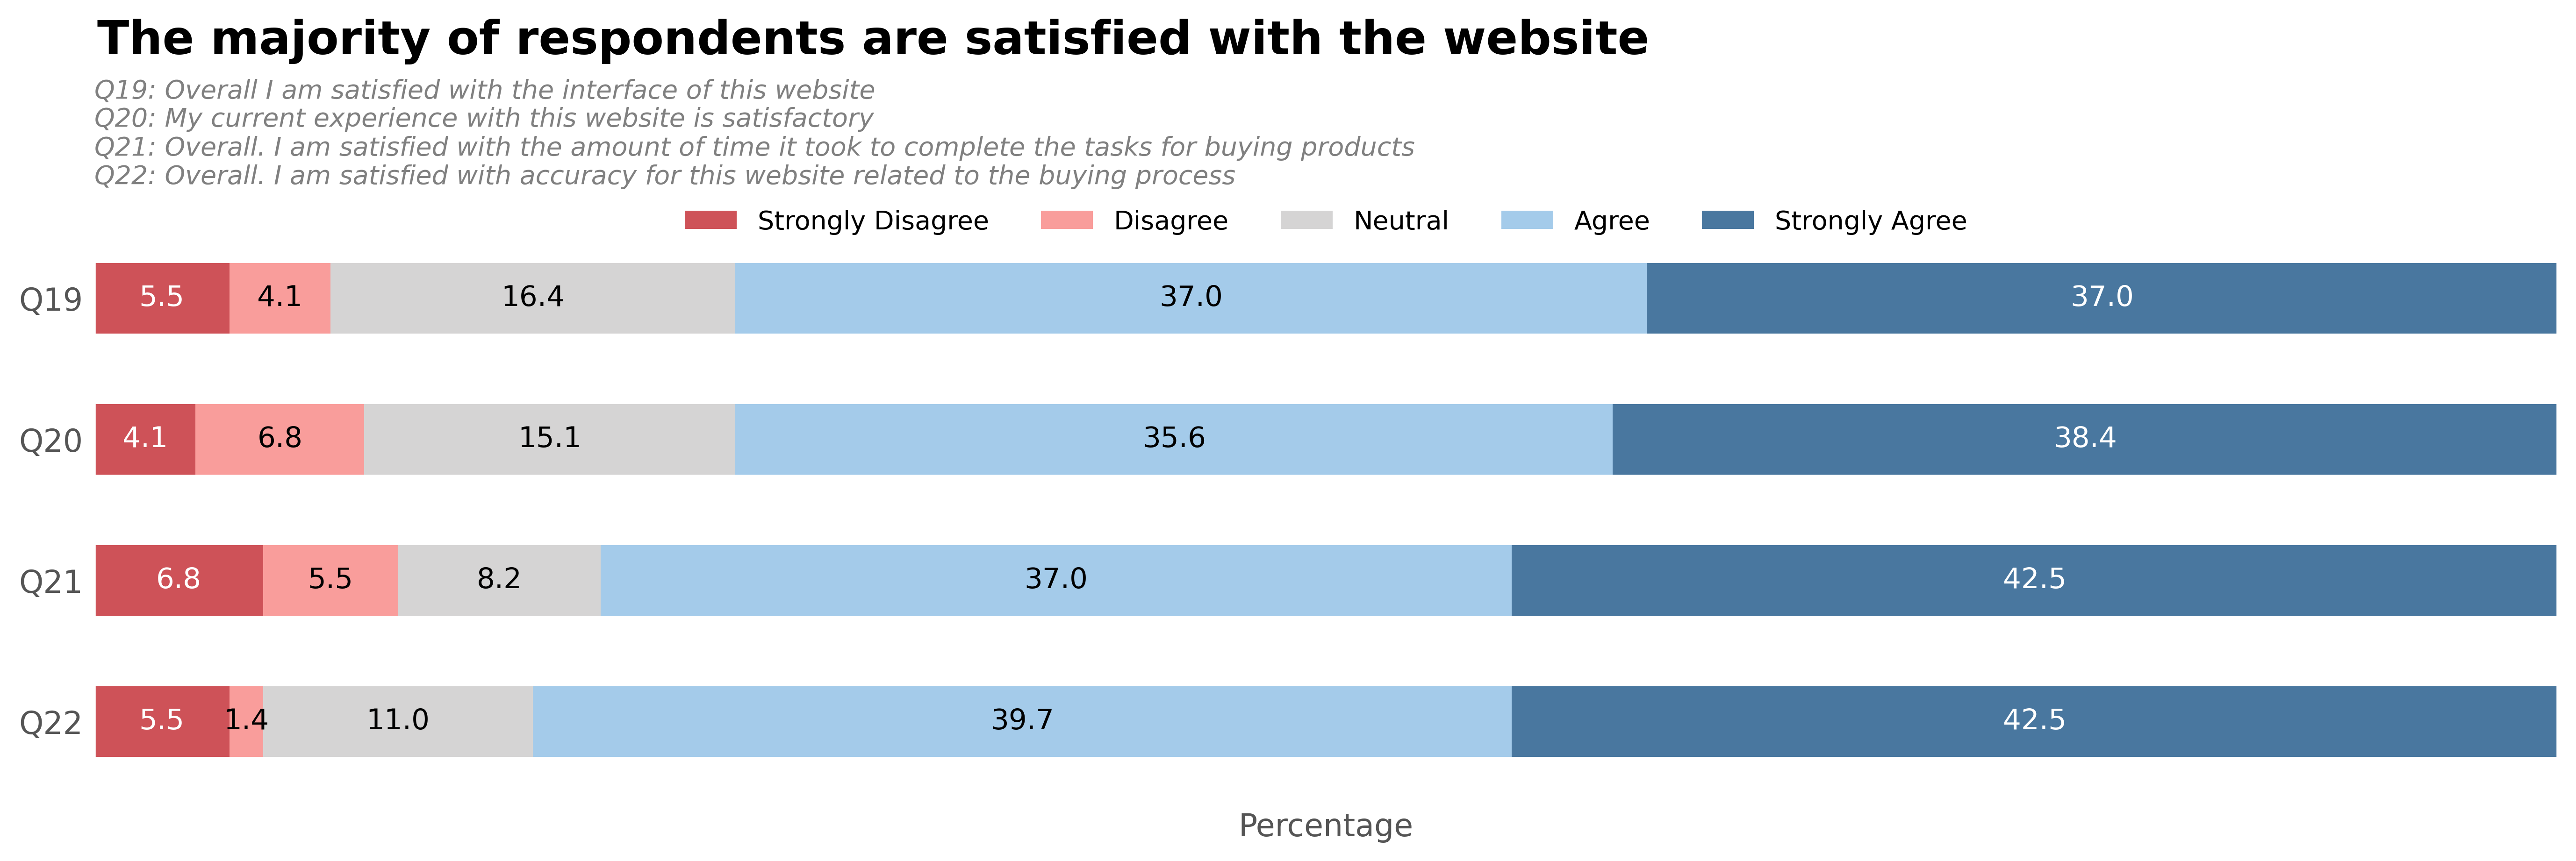

In [59]:
# Select specific questions to visualize
selected_questions = percentages.loc['Q22':'Q19', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('The majority of respondents are satisfied with the website', 
             y=1.16, size=18, x=0.37, weight='bold')
ax.set_title('Q19: Overall I am satisfied with the interface of this website\n' 
             'Q20: My current experience with this website is satisfactory\n' 
             'Q21: Overall. I am satisfied with the amount of time it took to complete the tasks for buying products\n' 
             'Q22: Overall. I am satisfied with accuracy for this website related to the buying process', 
             fontsize=10, loc='left', y=1.05, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.7 Trust**

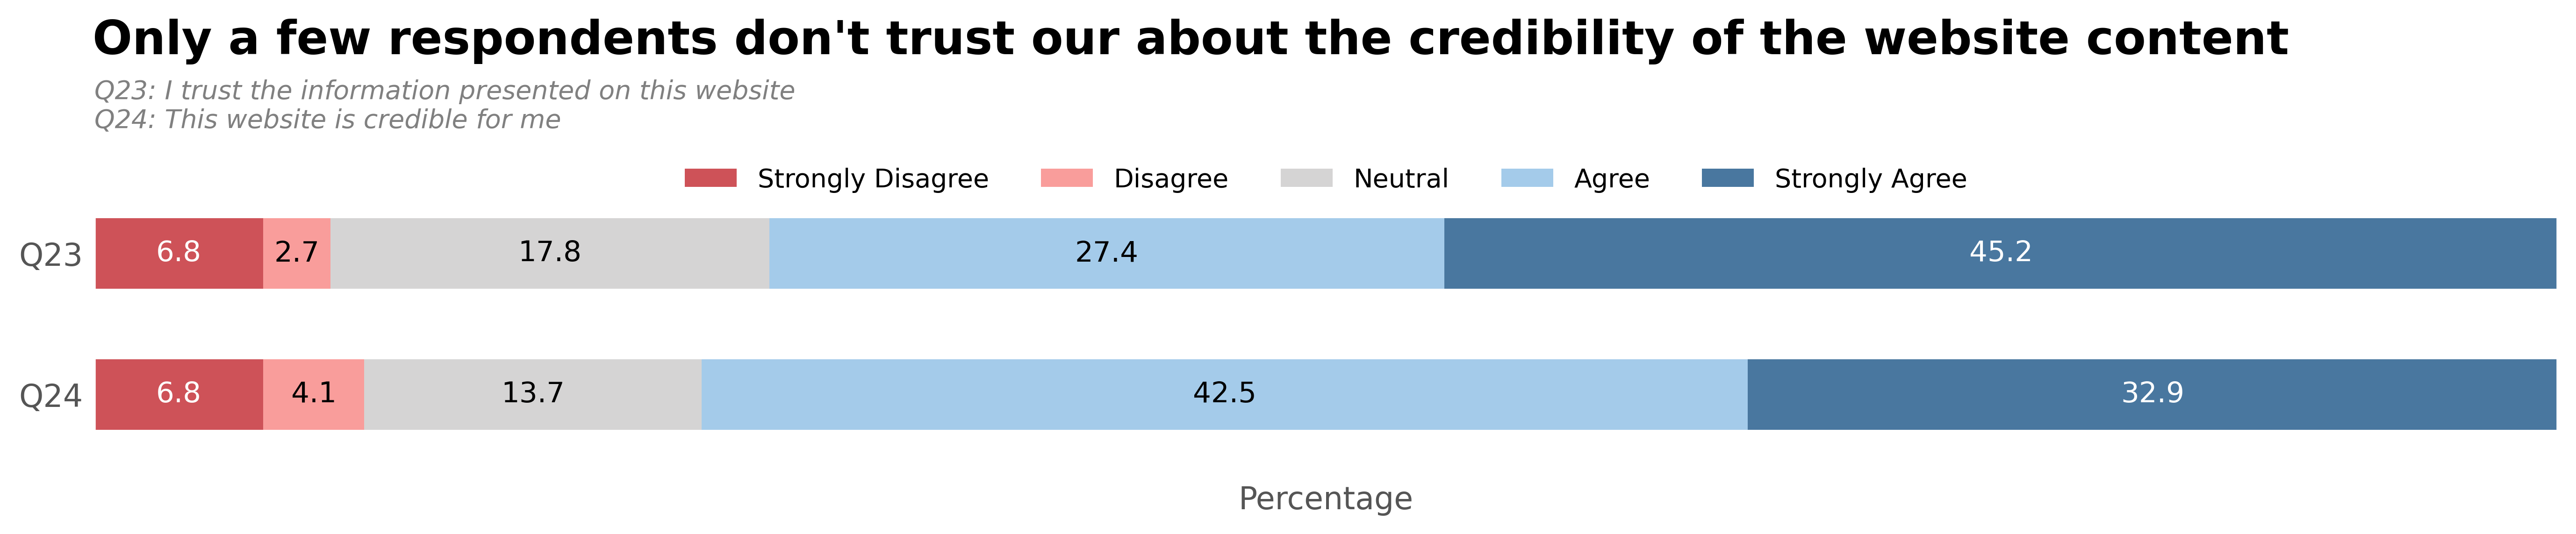

In [60]:
# select specific questions to visualize
selected_questions = percentages.loc['Q24':'Q23', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Only a few respondents don\'t trust our about the credibility of the website content', 
             y=1.32, size=18, x=0.470, weight='bold')
ax.set_title('Q23: I trust the information presented on this website\n' 
             'Q24: This website is credible for me\n', 
             fontsize=10, loc='left', y=1.04, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

#### **3.3.8 Loyalty**

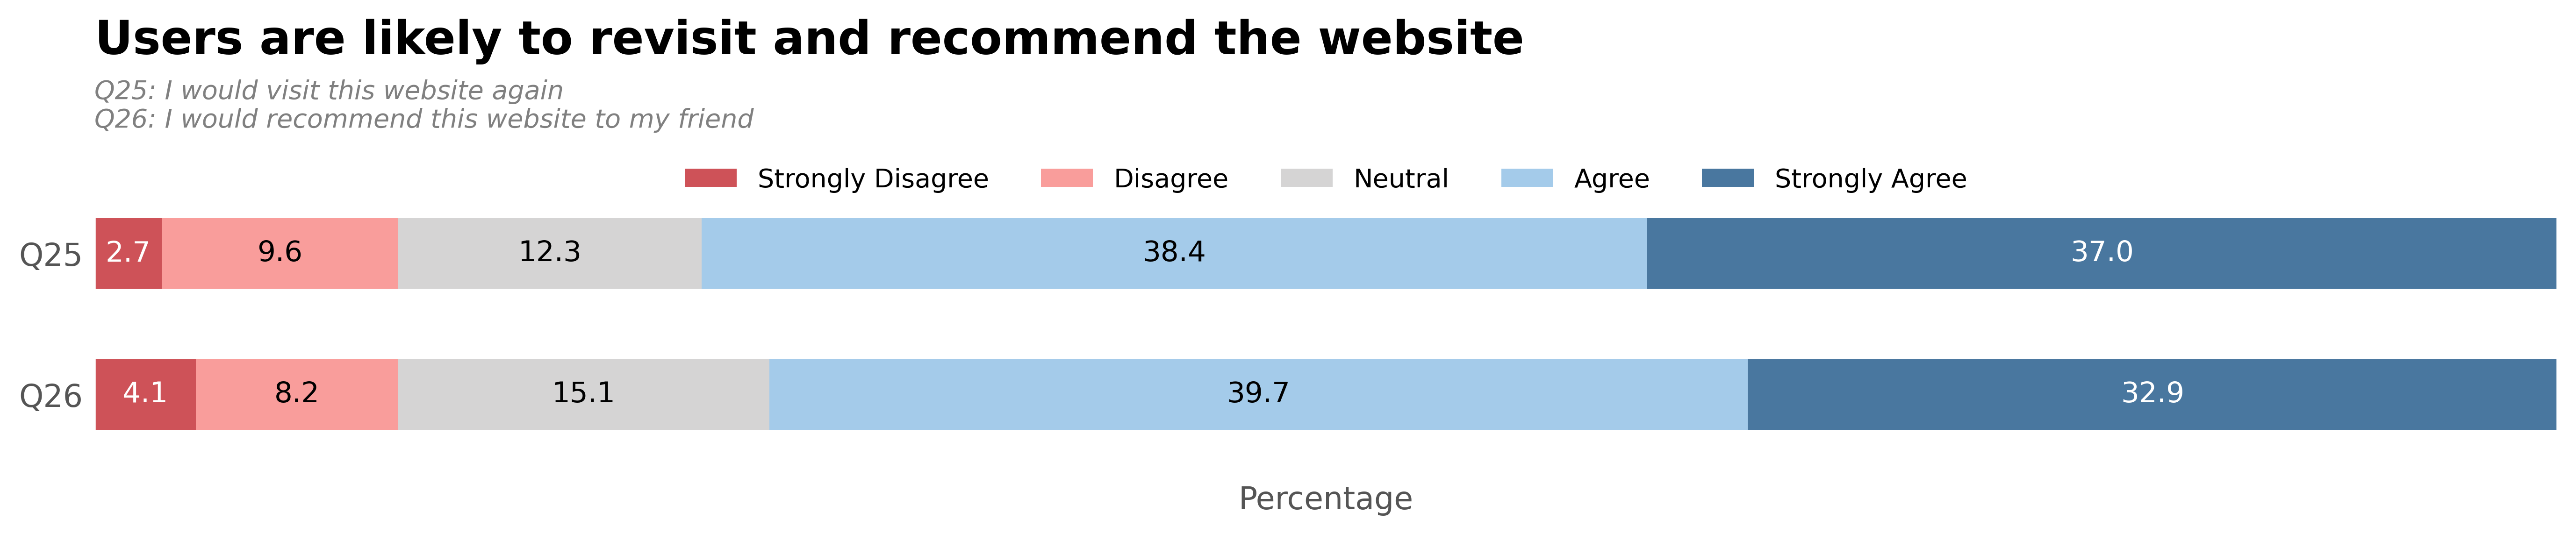

In [61]:
# select specific questions to visualize
selected_questions = percentages.loc['Q26':'Q25', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Users are likely to revisit and recommend the website', 
             y=1.32, size=18, x=0.35, weight='bold')
ax.set_title('Q25: I would visit this website again\n' 
             'Q26: I would recommend this website to my friend\n', 
             fontsize=10, loc='left', y=1.04, color='grey', style='italic')
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

## **3.4 References**
- Faisal, C. M. N., Gonzalez-Rodriguez, M., FernandezLanvin, D., & Andres-Suarez, J. De. (2017). Web Design Attributes in Building User Trust, Satisfaction, and Loyalty for a High Uncertainty Avoidance Culture. *IEEE Transactions on Human-Machine Systems*, 47(6), 847–859. https://doi.org/10.1109/THMS.2016.2620901

<h1 style='color:orange; text-align:center; font-weight:bold'>--END--</h1>

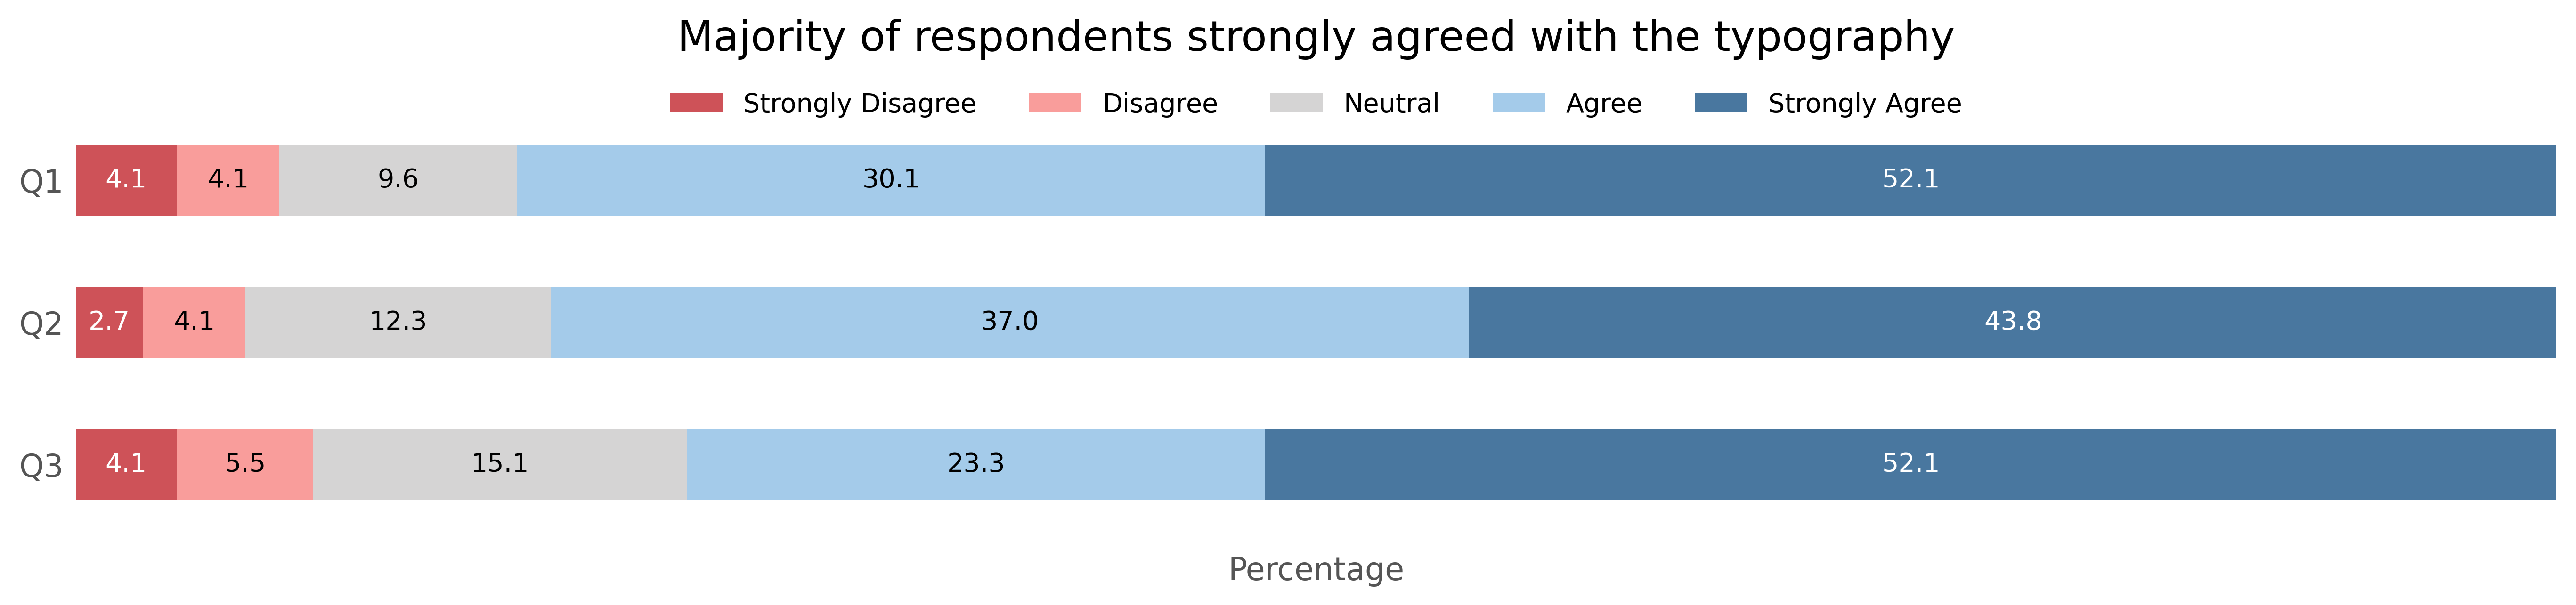

In [62]:
# select specific questions to visualize
selected_questions = percentages.loc['Q3':'Q1', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize data
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
ax.set_title('Majority of respondents strongly agreed with the typography',
              y=1.1, loc='center', size=16)
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)                                                         # keep limits for percentage scale
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12) # move y-ticks slightly to the left

# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
         # change color for Strongly Disagree and Strongly Agree
        label_color = 'white' if j == 0 or j == 4 else 'black' 
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=10)

ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()
